# COMPARISON BETWEEN THE TIME WHEN SOFTWARE TRIGGERS A CHANNEL AND WHEN THE OLFACTOMETER TRIGGERS THAT SPECIFIC VALVE TO START THE FLOW

In [25]:
from utils.data_loading import load_olf_registers, load_sw_register, load_rig_info
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def get_rig_n(base_path: str) -> str:
    return load_rig_info(base_path)["rig_name"]

def collapse_bool_df(df:pd.DataFrame, name:str = "Open"):
    """Finds the position of first True column per row in a boolean dataframe, and returns a dataframe with a single column with the index of that True value:
    Time    Col0    Col1    Col2            Time    Open
    1       True    False   False           1       0
    2       False   False   True    --->    2       2
    3       False   False   True            3       2
    4       False   True    False           4       1
    """

    pos = df.idxmax(axis=1).str.extract(r'(\d+)', expand=False).astype(int) 

    # keep only rows where at least one value is True
    pos = pos[df.any(axis=1)]
    pos.name = name

    return pos.to_frame()

import numpy as np
import pandas as pd

def compare_tiggers(
    trigger1: pd.DataFrame,
    *others: pd.DataFrame,
    mode_round_decimals: int = 6,
) -> list[pd.DataFrame, pd.DataFrame]:
    """
    Compare a reference trigger (trigger1) against one or more other triggers.
    Each trigger is a DataFrame with a time index and a single integer column (channel id).

    Matching is done per channel: for each reference event, pick the closest event
    in each other trigger (no tolerance threshold). One-to-one matching (no re-use).

    Parameters
    ----------
    trigger1 : pd.DataFrame
        Reference trigger (time index, single int column)
    *others : pd.DataFrame
        One or more triggers to compare to reference
    mode_round_decimals : int, default 6
        Number of decimals to round absolute deltas to before computing the mode.

    Returns
    -------
    [results, summary] : list[pd.DataFrame, pd.DataFrame]
        results: per-event matches and signed deltas (per comparator)
        summary: per-channel stats (events, matchedN, match_rateN, mean/std/max abs delta, mode abs delta)
    """

    def to_series(df: pd.DataFrame) -> pd.Series:
        if isinstance(df, pd.Series):
            s = df.copy()
        else:
            if df.shape[1] != 1:
                raise ValueError("Each trigger must have exactly one column.")
            s = df.iloc[:, 0].copy()
        s = s.dropna()
        # ensure int channel ids and sort by time
        s = s.astype(int).sort_index()
        return s

    ref = to_series(trigger1)
    other_series = [to_series(x) for x in others]

    # Prepare results aligned to reference events
    results = pd.DataFrame(index=ref.index)
    results["channel"] = ref.values

    channels = sorted(pd.unique(ref.values))

    def match_times_nearest(t_ref: np.ndarray, t_other: np.ndarray):
        """
        Greedy one-to-one nearest neighbor matching without tolerance.
        Ties are broken by choosing the earlier (smaller) t_other.
        """
        n, m = len(t_ref), len(t_other)
        i = j = 0
        matched_time = np.full(n, np.nan, dtype=float)
        delta = np.full(n, np.nan, dtype=float)
        matched = np.zeros(n, dtype=bool)

        if n == 0 or m == 0:
            return matched_time, delta, matched

        while i < n and j < m:
            # Walk j toward the local nearest to current t_ref[i]
            while j + 1 < m and abs(t_other[j + 1] - t_ref[i]) <= abs(t_other[j] - t_ref[i]):
                j += 1

            # Consider neighbor on the left as well (tie -> earlier)
            k = j
            if j > 0:
                left_diff = abs(t_other[j - 1] - t_ref[i])
                cur_diff = abs(t_other[j] - t_ref[i])
                if left_diff < cur_diff or (left_diff == cur_diff):
                    k = j - 1

            matched_time[i] = t_other[k]
            delta[i] = t_other[k] - t_ref[i]  # signed delta
            matched[i] = True

            # consume k and move on
            j = k + 1
            i += 1

        # remaining ref events (if any) stay unmatched (NaN, False)
        return matched_time, delta, matched

    # Do per-channel matching for each comparator
    for k, oth in enumerate(other_series, start=1):
        matched_time_all = np.full(results.shape[0], np.nan, dtype=float)
        delta_all = np.full(results.shape[0], np.nan, dtype=float)
        matched_mask_all = np.zeros(results.shape[0], dtype=bool)

        for v in channels:
            # Indices (into results/ref) for this channel
            idx_ref = np.where(ref.values == v)[0]
            if idx_ref.size == 0:
                continue

            # Times for ref & other for this channel
            t_ref = ref.index.values[idx_ref]
            t_oth = oth.index.values[oth.values == v]

            if t_oth.size == 0:
                continue

            mtime, dlt, msk = match_times_nearest(t_ref, t_oth)

            matched_time_all[idx_ref] = mtime
            delta_all[idx_ref] = dlt
            matched_mask_all[idx_ref] = msk

        results[f"matched_time_{k}"] = matched_time_all
        results[f"delta_{k}"] = delta_all
        results[f"matched_{k}"] = matched_mask_all

    # Summary per channel (using absolute deltas)
    rows = []
    for v in channels:
        ch_mask = results["channel"] == v
        events = int(ch_mask.sum())
        row = {"channel": v, "events": float(events)}
        for k in range(1, len(other_series) + 1):
            m = results.loc[ch_mask, f"matched_{k}"]
            d = results.loc[ch_mask, f"delta_{k}"]
            matched_count = int(m.sum())
            row[f"matched{k}"] = float(matched_count)
            row[f"match_rate{k}"] = matched_count / events if events else np.nan

            if matched_count:
                absd = d[m].abs()
                row[f"mean_delta{k}"] = float(absd.mean())
                row[f"std_delta{k}"] = float(absd.std(ddof=0))

                # Mode of absolute deltas with rounding to stabilize for continuous data
                absd_r = absd.round(mode_round_decimals)
                modes = absd_r.mode()
                row[f"mode_delta{k}"] = float(modes.iloc[0]) if not modes.empty else np.nan
            else:
                row[f"mean_delta{k}"] = np.nan
                row[f"std_delta{k}"] = np.nan
                row[f"mode_delta{k}"] = np.nan

        rows.append(row)

    summary = pd.DataFrame(rows).set_index("channel").sort_index()

    return [results, summary]

def plot_two_triggers(trigger1: pd.DataFrame, tr1_name:str, trigger2: pd.DataFrame,  tr2_name:str, xlim:set|None = None, plot_title:str|None = None) -> None:
    """Plots two dataframes with this structure:
    Time    Open
    1.2     0
    2.0     2
    3.4     2
    4.1     1
    """
    plt.figure(figsize=(14, 8))

    # Normalize for readability
    arrays = []

    trigger1_colors = ["blue", "brown", "forestgreen"]
    trigger2_colors = ["cyan", "orange", "lawngreen"]

    for v in (0,1,2):  
        arrays.append(trigger2.index[trigger2.iloc[:, 0] == v].values)
        arrays.append(trigger1.index[trigger1.iloc[:, 0] == v].values)
    t0 = min(arr.min() for arr in arrays if arr.size > 0)

    for i, v in enumerate((0,1,2)):
        mask = trigger1.iloc[:, 0] == v
        spec_t = trigger1.index.values[mask] - t0
        plt.eventplot(spec_t, lineoffsets=1.5, linelengths=3, linewidths=0.75, colors=trigger2_colors[i])
    
    for i, v in enumerate((0,1,2)):
        mask = trigger2.iloc[:, 0] == v
        t = trigger2.index[mask].values - t0
        plt.eventplot(t, lineoffsets=i+0.5, linelengths=0.95, linewidths=0.5, colors=trigger1_colors[i])
    
    plt.ylim(0, 3) # Set y-axis limits
    plt.xlim(xlim)
    plt.legend([f"{tr1_name}-ch0",f"{tr1_name}-ch1",f"{tr1_name}-ch2",f"{tr2_name}-ch0",f"{tr2_name}",f"{tr2_name}-ch2"])
    plt.xlabel("Time")
    if plot_title: plt.title(plot_title)
    plt.tight_layout()
    plt.show()

def run_analysis_in_single_folder(base_path: str, rig_n: str|None = None, xlim: set|None = None) -> list[pd.DataFrame, pd.DataFrame]:
    # OLFACTOMETER CHANNELS TRIGGER
    olf_reg = load_olf_registers(base_path)
    olf_reg['OdorValveState'] = olf_reg['OdorValveState'].drop(columns=['Valve3'])
    olf_trigger = collapse_bool_df(olf_reg['OdorValveState'], name="olf_trigger")  
    #olf_trigger = olf_trigger.iloc[1:, :] # Remove the first row (always an outlier)

    # ENDVALVE TRIGGER    
    endv_trigger  = olf_reg['EndValveState']['EndValve0']*1
    endv_trigger.name = "endvalve_trigger"

    # PATH TRIGGER
    path_reg = load_sw_register(base_path, "ActivePatch")
    path_trigger = path_reg['odor_specification'].str['index'].to_frame('path_trigger').set_index(path_reg['timestamp'])
    
    
    # SITES TRIGGER
    site_reg = load_sw_register(base_path, "ActiveSite")
    site_trigger = site_reg['odor_specification'].str['index'].to_frame('site_trigger').set_index(site_reg['timestamp']).fillna(0)  

    # print(olf_trigger, endv_trigger, path_trigger, site_trigger)

    results, summary = compare_tiggers(olf_trigger, site_trigger, path_trigger)  
    print(summary)


    plot_title = (base_path + " - " + rig_n) if rig_n else base_path
    plot_two_triggers(path_trigger, "path", olf_trigger, "Olf", xlim=xlim, plot_title=plot_title)
    
    #plot_two_triggers(path_trigger, "path", site_trigger, "site", xlim=xlim, plot_title=plot_title)

    #plot_two_triggers(site_trigger, "site", olf_trigger, "Olf", xlim=xlim, plot_title=plot_title)


    return results, summary


Loaded rig info: Computer - DT300043, Rig - 13A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          18.0      18.0     1.000000     0.493575    0.015116     0.511296   
1         254.0     253.0     0.996063     1.617406    2.979225     0.475296   
2         260.0     260.0     1.000000     1.494492    2.761297     0.494304   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            18.0     1.000000     2.239019    4.975921     0.481280  
1           250.0     0.984252    20.336541   17.643901     0.474304  
2           232.0     0.892308    26.824997   24.289834     0.495296  


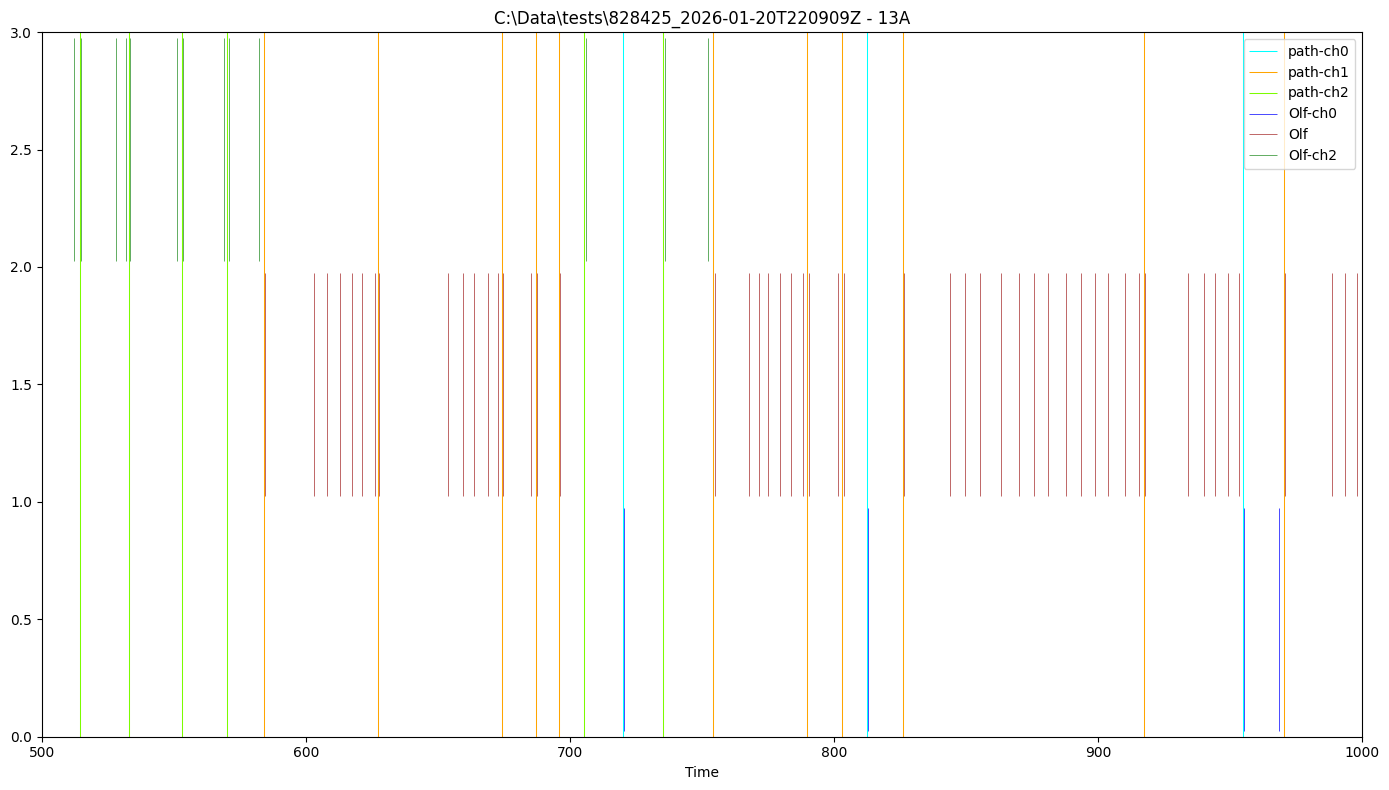

(              channel  matched_time_1   delta_1  matched_1  matched_time_2  \
 Time                                                                         
 5.019224e+06        1    5.019231e+06  6.722720       True    5.019223e+06   
 5.019235e+06        1    5.019235e+06 -0.464320       True    5.019237e+06   
 5.019238e+06        1    5.019235e+06 -2.911296       True    5.019237e+06   
 5.019251e+06        1    5.019255e+06  3.547712       True    5.019251e+06   
 5.019258e+06        2    5.019267e+06  8.382688       True    5.019258e+06   
 ...               ...             ...       ...        ...             ...   
 5.023023e+06        1    5.023023e+06 -0.508288       True    5.023041e+06   
 5.023029e+06        1    5.023029e+06 -0.507296       True             NaN   
 5.023035e+06        1    5.023035e+06 -0.508320       True             NaN   
 5.023040e+06        1    5.023039e+06 -0.508288       True             NaN   
 5.023041e+06        1             NaN       NaN    

In [26]:
#Single analysis

base_path = r"C:\Data\tests\828425_2026-01-20T220909Z"
rig = get_rig_n(base_path)
run_analysis_in_single_folder(base_path, rig_n=rig, xlim=(500,1000))

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           9.0       9.0          1.0     0.013259    0.010198     0.007488   
1         184.0     184.0          1.0     1.365534    3.235909     0.003488   
2         262.0     262.0          1.0     0.762519    2.520945     0.003488   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             9.0     1.000000     0.017259    0.009827     0.010464  
1           184.0     1.000000    29.704606   30.614738     0.009504  
2           261.0     0.996183    43.065222   40.117916     0.010496  


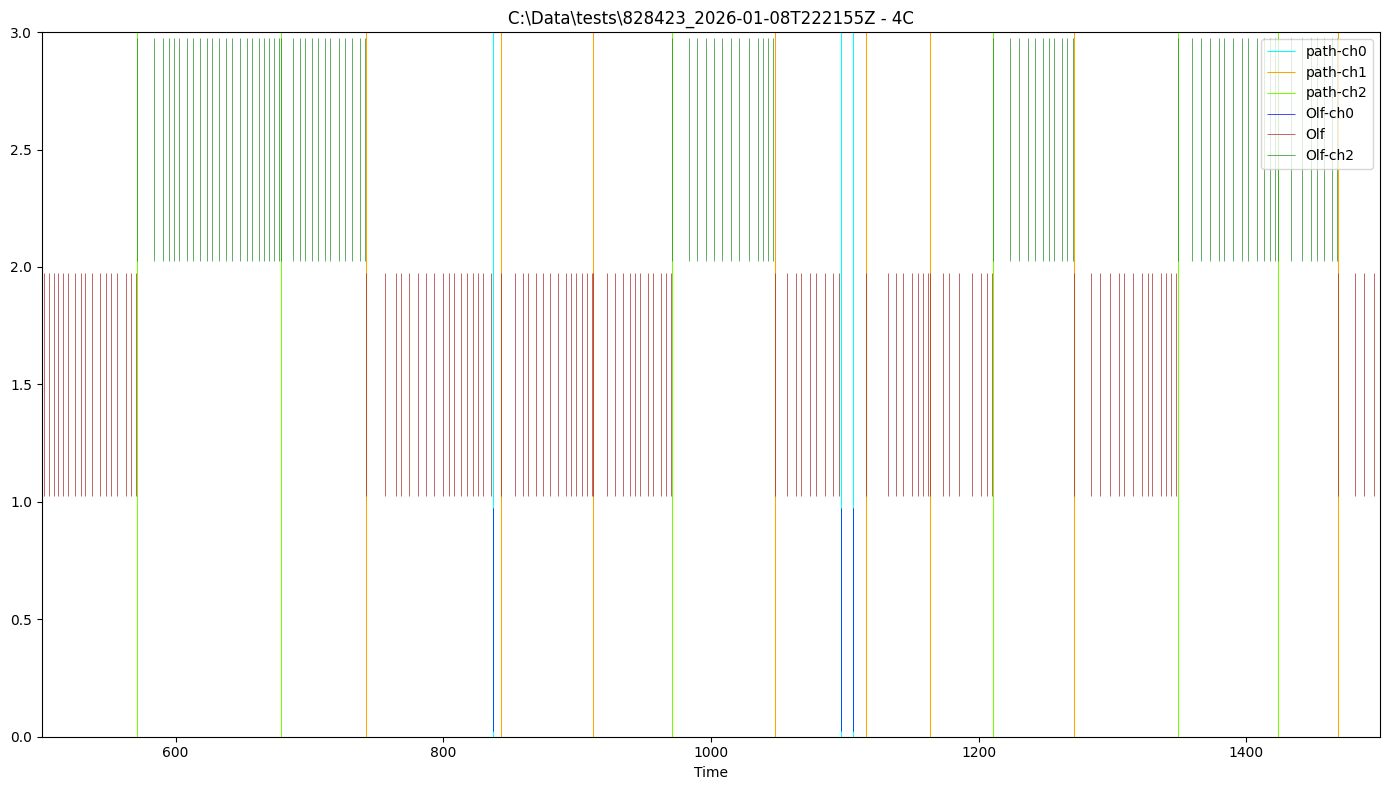

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          10.0      10.0          1.0     0.013133    0.008970     0.007232   
1         181.0     181.0          1.0     0.823497    2.067194     0.003232   
2         296.0     296.0          1.0     0.517609    1.874508     0.003232   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            10.0          1.0     0.944326    2.759685     0.018240  
1           181.0          1.0    43.461032   43.496594     0.010208  
2           296.0          1.0    33.675873   24.428918     0.011232  


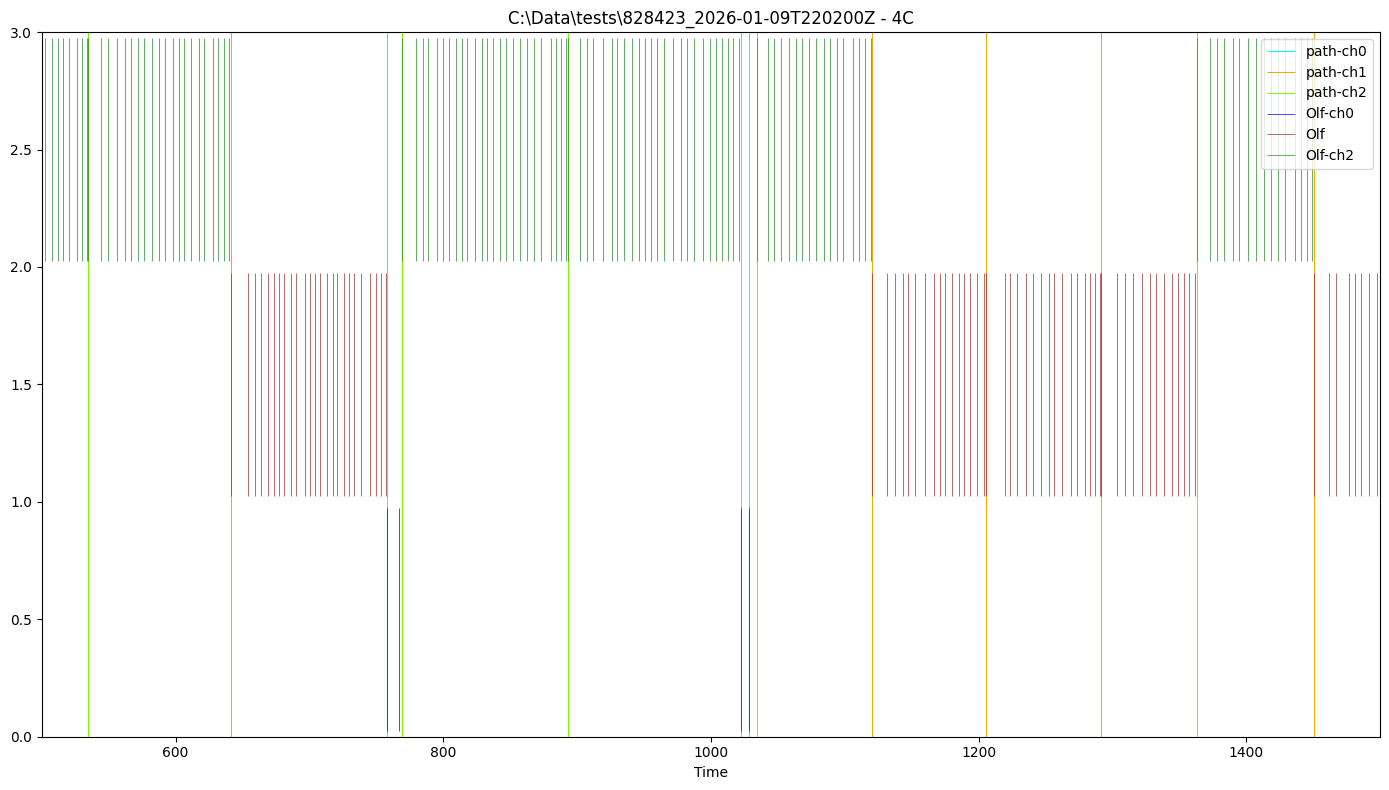

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           2.0       2.0     1.000000     0.010832    0.003504     0.007328   
1         222.0     222.0     1.000000     0.793695    2.568224     0.003360   
2         273.0     272.0     0.996337     0.509241    1.878723     0.002336   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             2.0          1.0     0.016832    0.005504     0.011328  
1           222.0          1.0    18.517770   18.057980     0.010336  
2           273.0          1.0    39.402447   30.736029     0.009344  


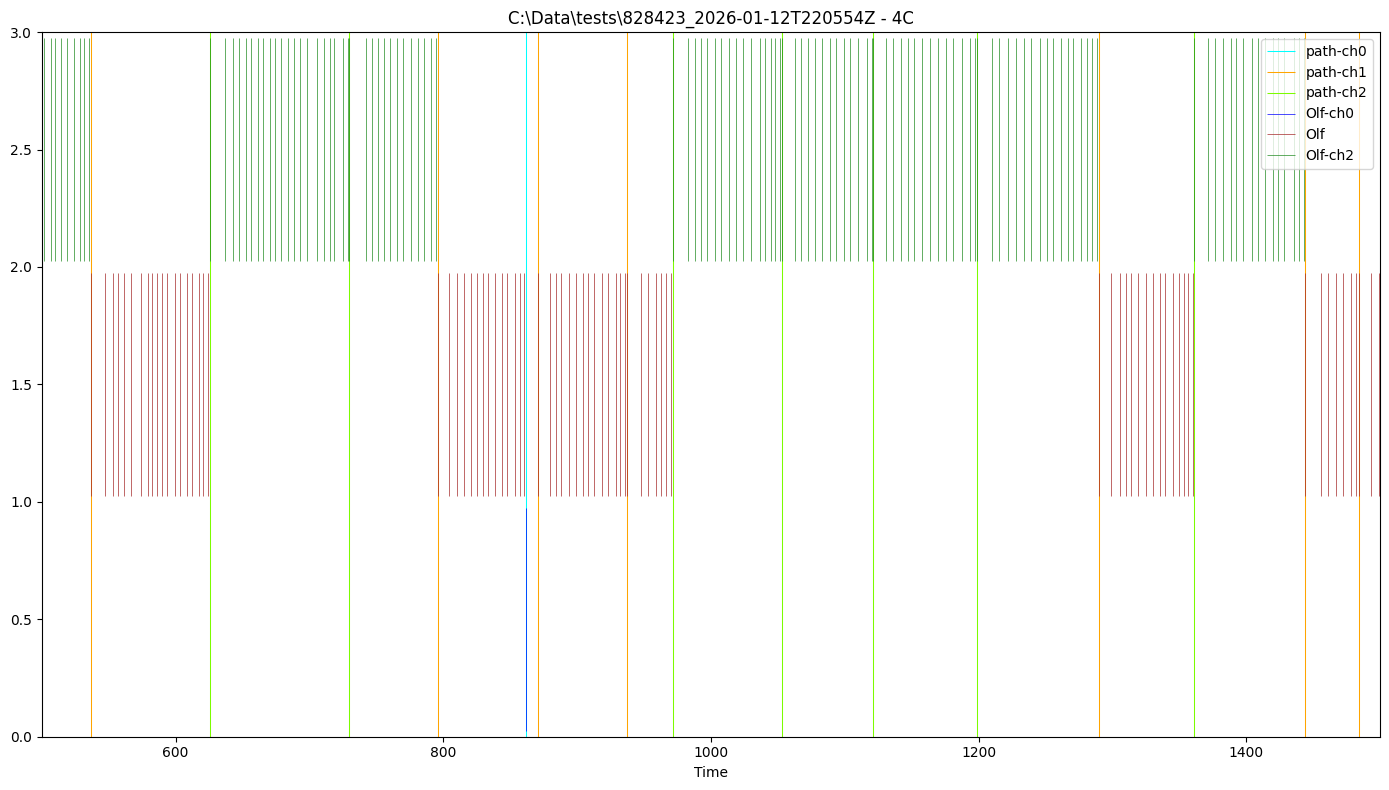

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           5.0       5.0          1.0     0.009798    0.001679     0.007776   
1         223.0     223.0          1.0     0.553391    1.905663     0.001792   
2         277.0     277.0          1.0     0.485788    1.997099     0.001792   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             5.0          1.0     0.016992    0.006795     0.009792  
1           223.0          1.0    27.549591   23.506838     0.009792  
2           277.0          1.0    39.470388   31.872853     0.010784  


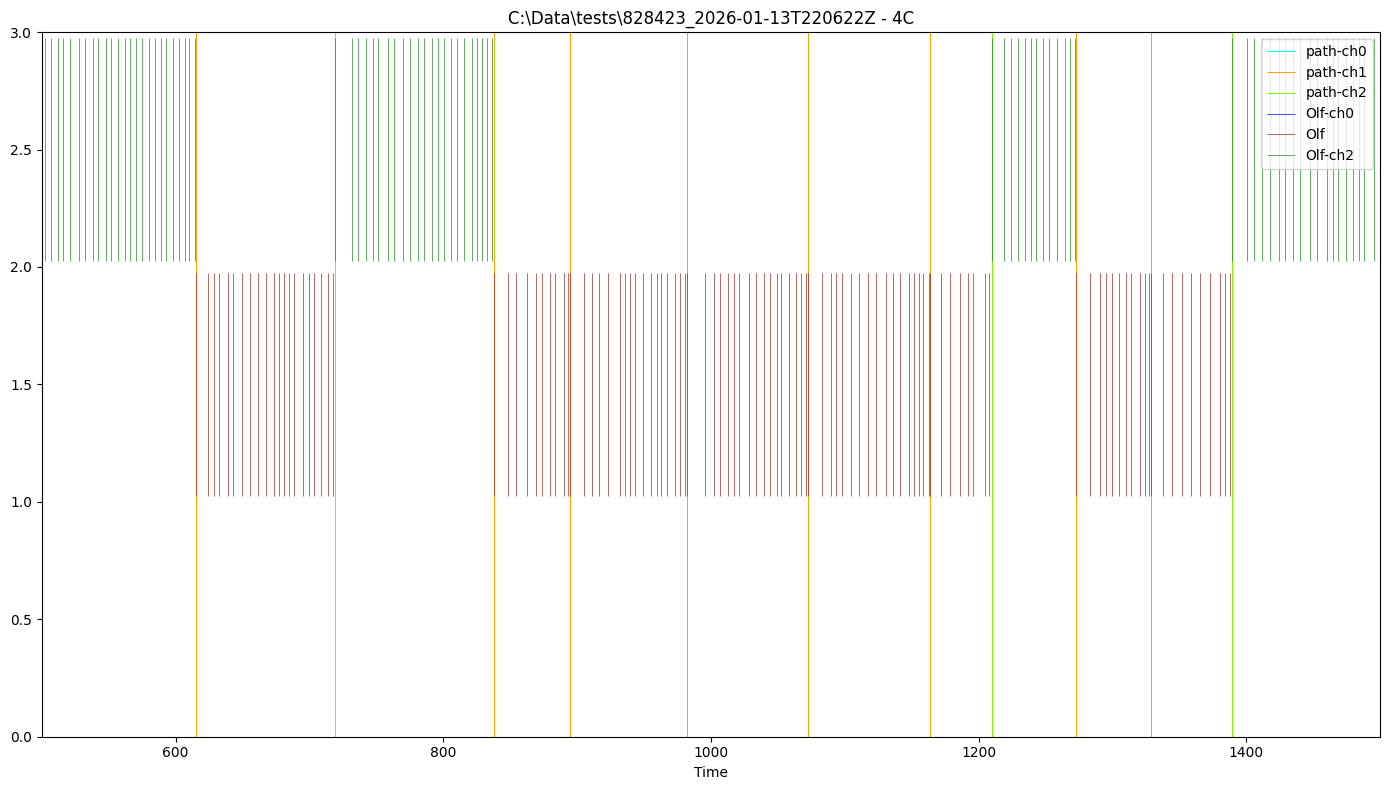

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          10.0      10.0          1.0     0.012166    0.005988     0.007264   
1         168.0     168.0          1.0     1.555163    4.303670     0.003264   
2         259.0     259.0          1.0     0.917750    2.948848     0.003264   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            10.0          1.0     0.020963    0.010802     0.009248  
1           168.0          1.0    16.879844   15.700092     0.010272  
2           259.0          1.0    27.724766   24.934481     0.010272  


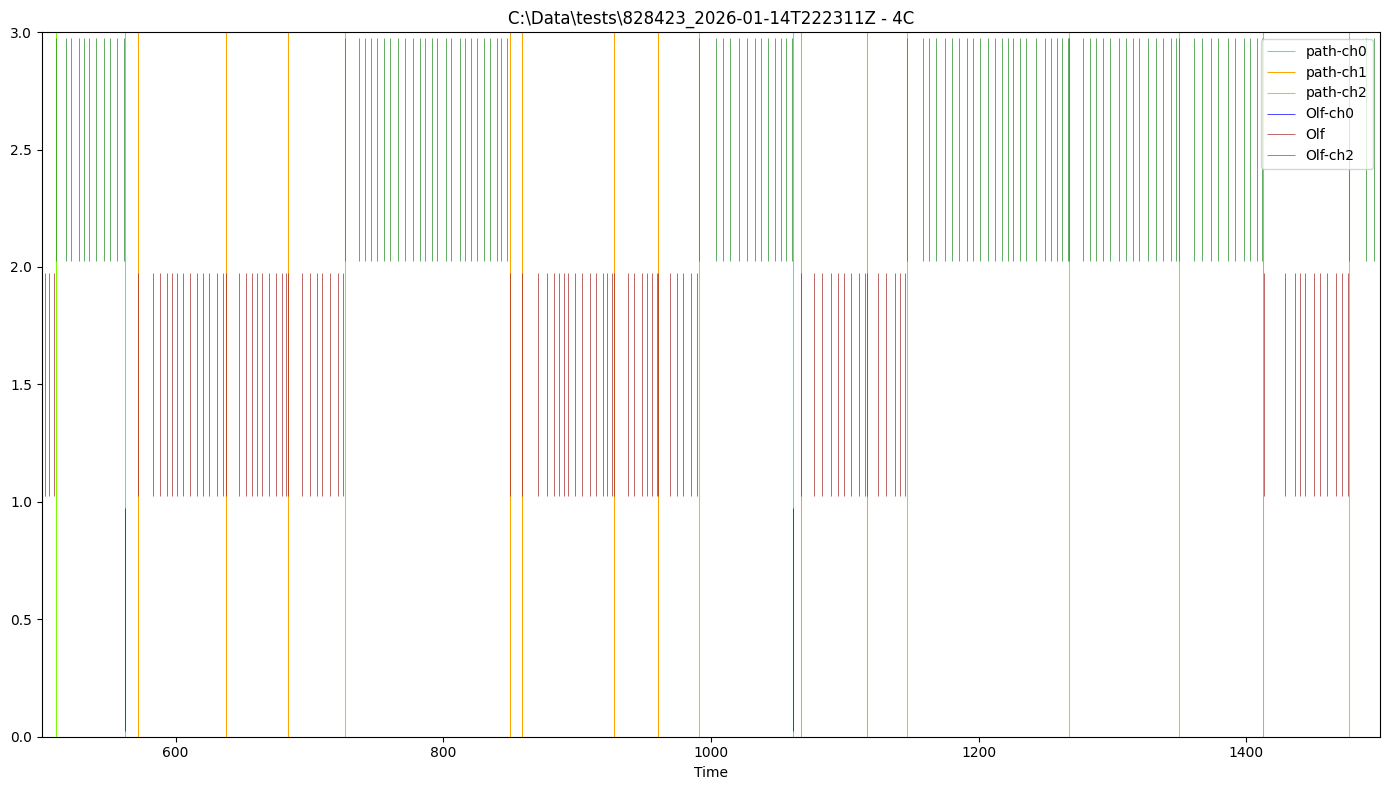

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          11.0      11.0          1.0     0.023508    0.036061     0.007680   
1         139.0     139.0          1.0     1.780305    4.518621     0.001696   
2         288.0     288.0          1.0     0.754857    2.588168     0.002688   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            11.0     1.000000     0.071325    0.170396     0.009696  
1           139.0     1.000000    17.820332   16.487302     0.009696  
2           286.0     0.993056    21.740264   19.392333     0.009696  


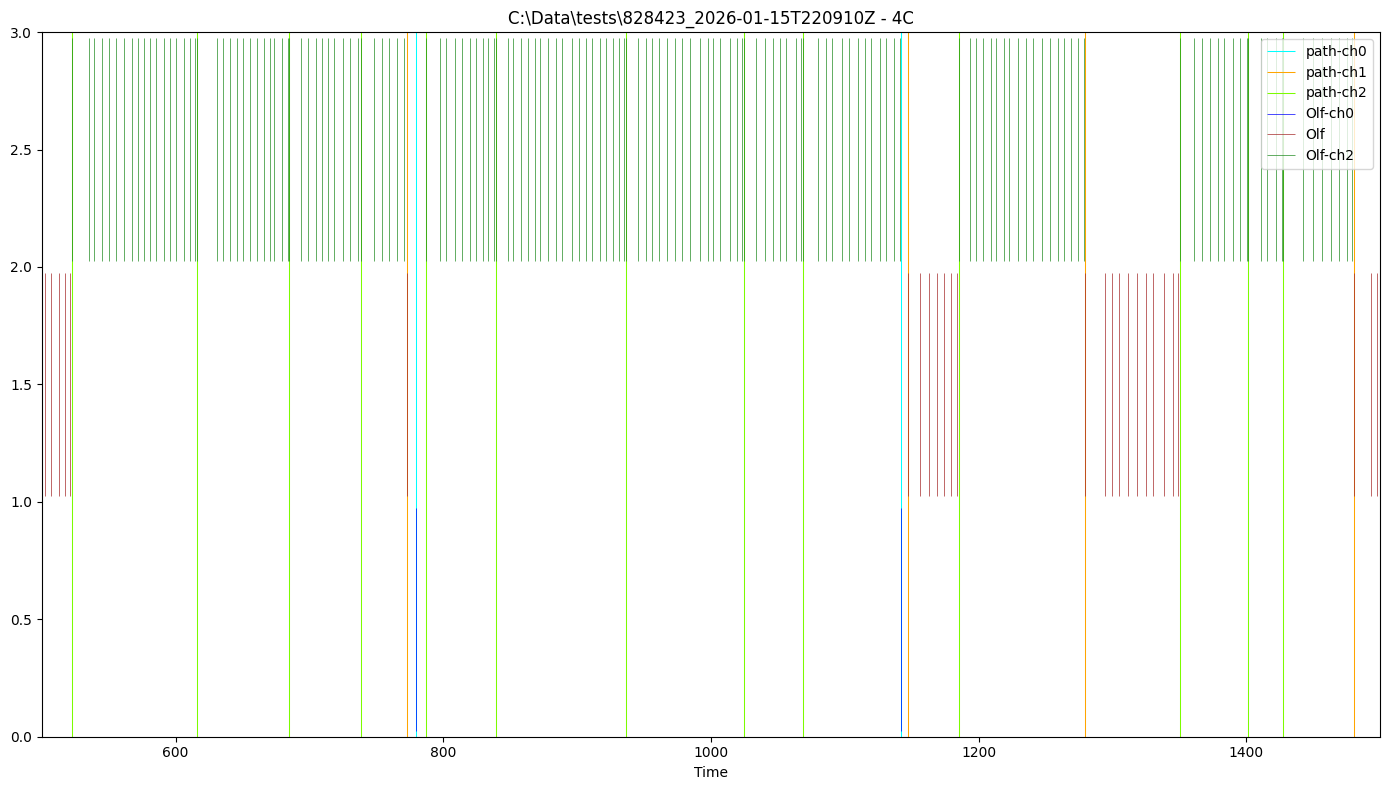

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           7.0       7.0     1.000000     0.013710    0.006869     0.006016   
1         133.0     133.0     1.000000     0.659095    1.842583     0.004000   
2         245.0     244.0     0.995918     0.412718    1.634930     0.004000   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             7.0          1.0     0.021138    0.010838     0.008992  
1           133.0          1.0    19.546013   14.725851     0.008992  
2           245.0          1.0    29.596529   23.267523     0.008992  


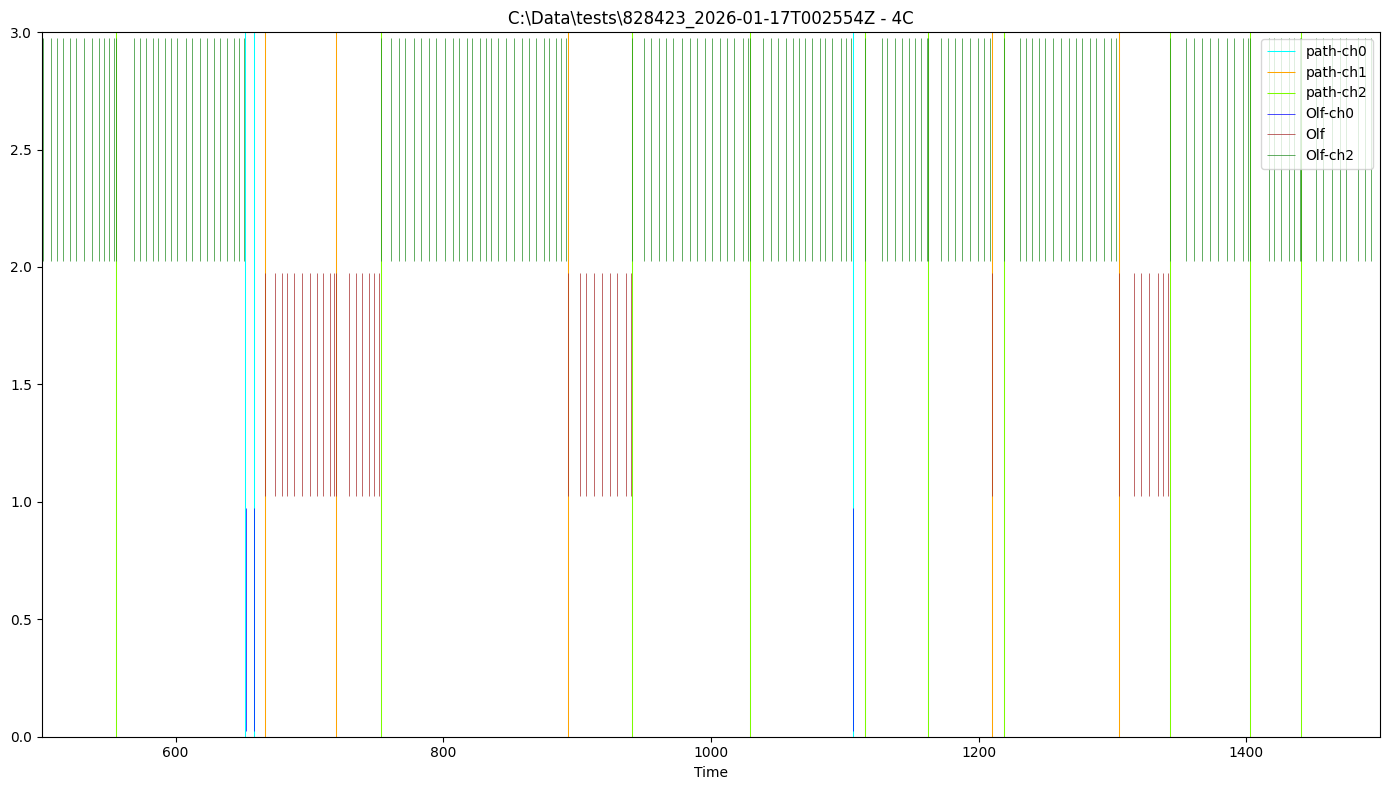

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           2.0       2.0          1.0     0.013840    0.002512     0.011328   
1          76.0      76.0          1.0     1.029347    1.990481     0.004320   
2         284.0     284.0          1.0     0.314793    1.314736     0.003328   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             2.0          1.0     0.017840    0.004496     0.013344  
1            76.0          1.0    23.246638   21.967752     0.010336  
2           284.0          1.0    38.448917   30.354362     0.009344  


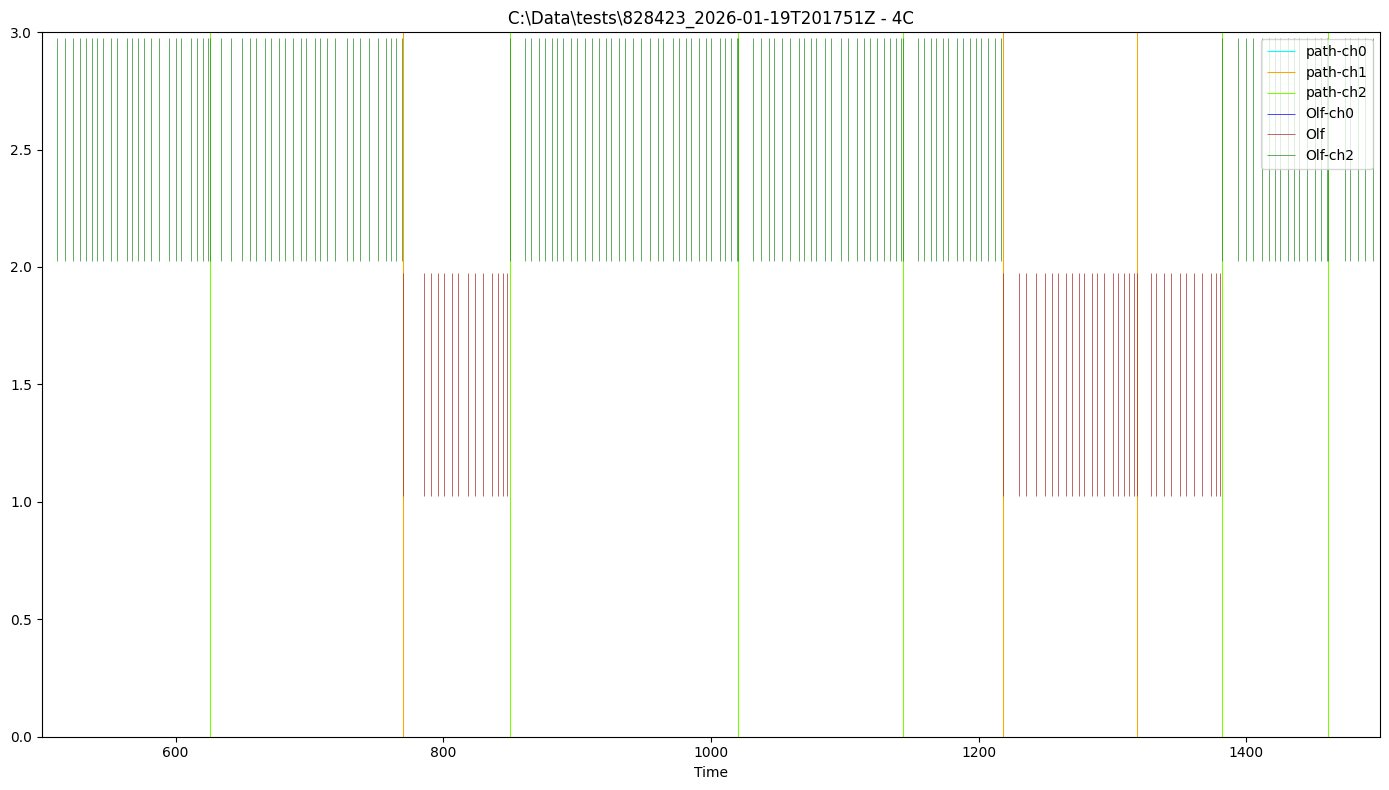

Loaded rig info: Computer - DT714698, Rig - Ephys5
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           1.0       1.0          1.0     0.025696    0.000000     0.025696   
1          18.0      18.0          1.0     0.827173    1.811168     0.002720   
2         209.0     209.0          1.0     0.129915    0.750487     0.001728   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             1.0     1.000000     0.037696    0.000000     0.037696  
1            18.0     1.000000    35.501673   26.762762     0.015712  
2           193.0     0.923445    67.594873   43.224863     0.026720  


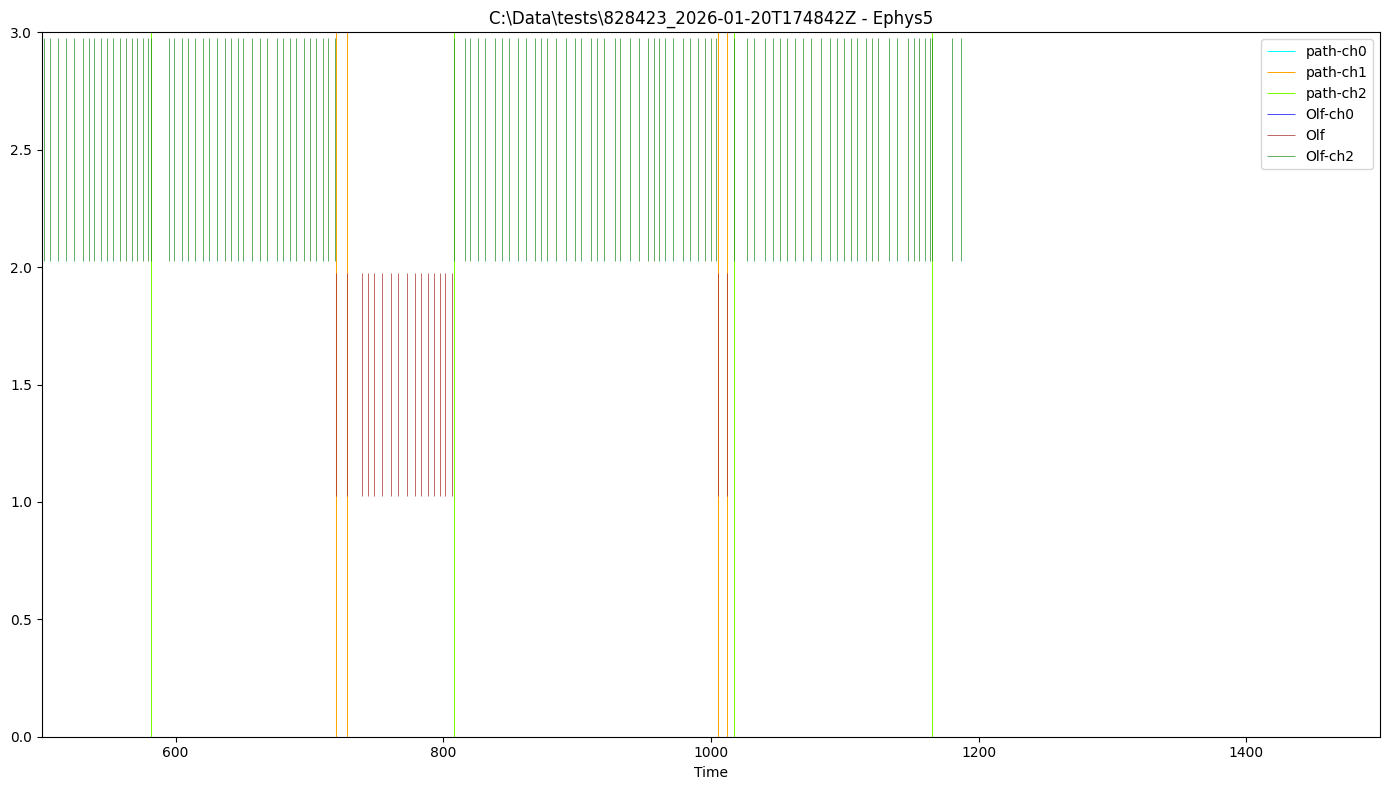

Loaded rig info: Computer - DT300185, Rig - 13D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          21.0      21.0          1.0     0.012422    0.010184     0.006944   
1         321.0     321.0          1.0     0.866526    2.726594     0.001952   
2         179.0     179.0          1.0     1.478197    2.919797     0.002944   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            21.0          1.0     1.751864    4.434131     0.008960  
1           321.0          1.0    36.459572   34.961033     0.009952  
2           179.0          1.0    13.763038   14.608215     0.009952  


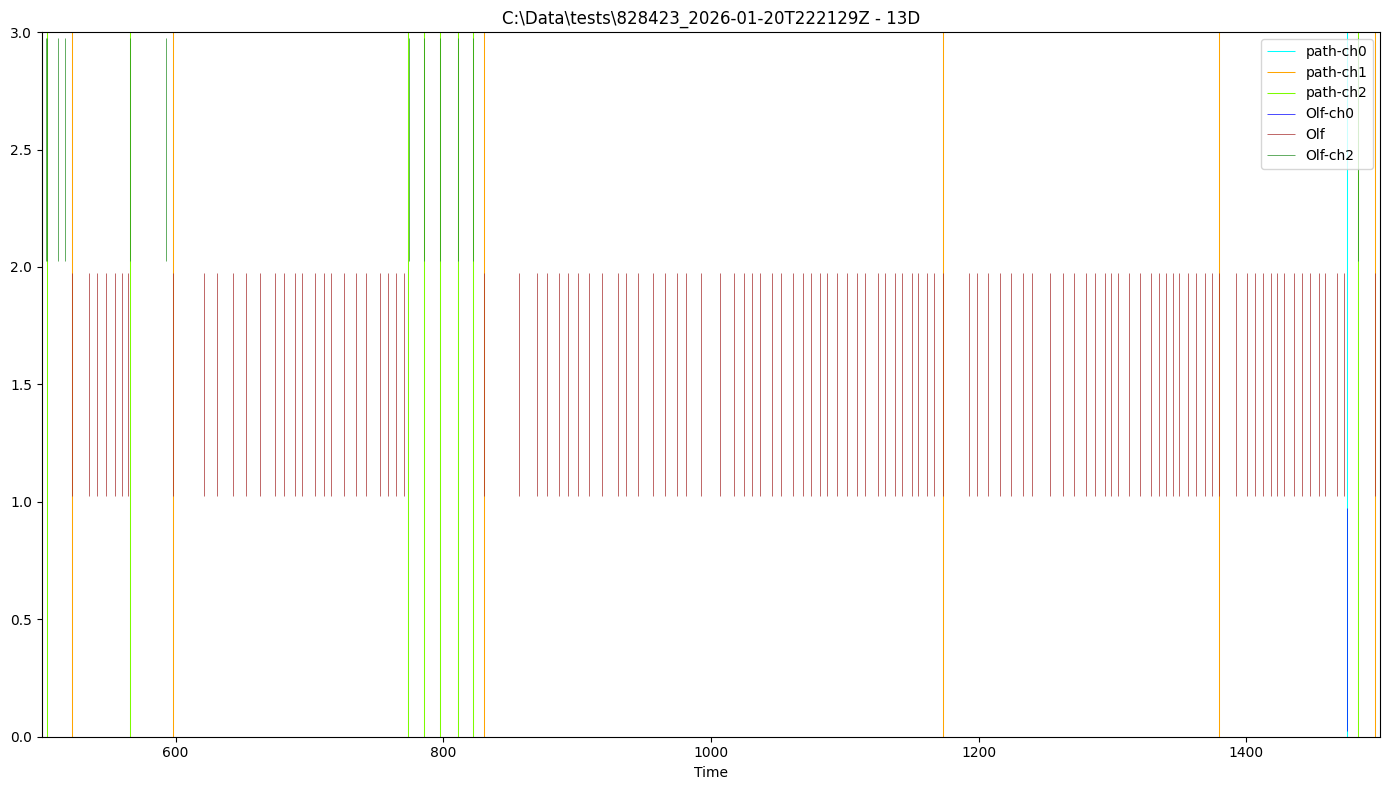

Loaded rig info: Computer - DT300185, Rig - 13D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          14.0      14.0     1.000000     0.014718    0.006208     0.016352   
1         133.0     132.0     0.992481     2.016686    3.404884     0.003360   
2         405.0     405.0     1.000000     0.687277    2.184983     0.003360   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            14.0          1.0     0.023003    0.011771     0.010368  
1           133.0          1.0     8.789864    9.274563     0.010368  
2           405.0          1.0    23.299789   18.736356     0.009344  


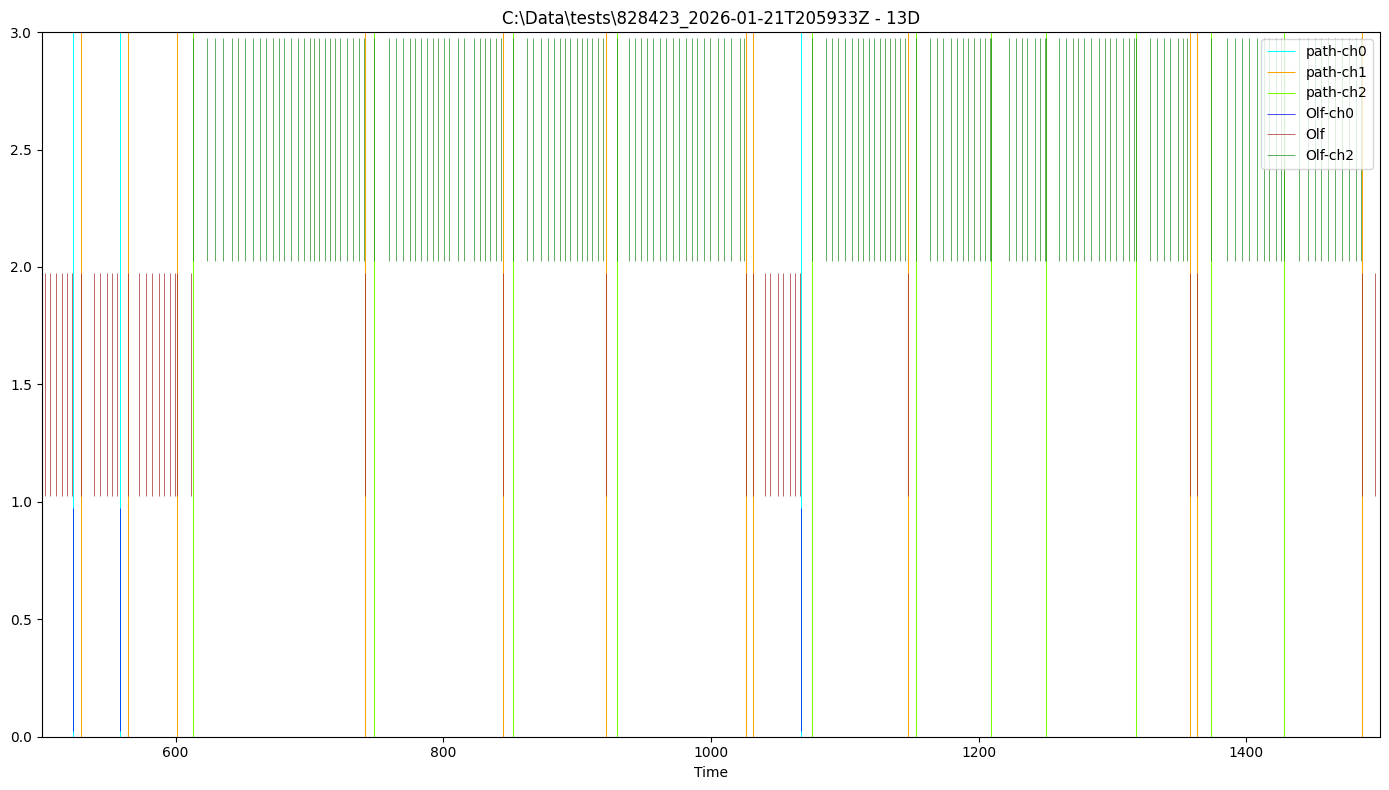

Loaded rig info: Computer - DT300043, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          11.0      11.0          1.0     0.012937    0.010165     0.007936   
1          87.0      87.0          1.0     3.102812    4.088090     0.002944   
2         306.0     306.0          1.0     0.932031    2.610809     0.002944   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            11.0          1.0     0.020567    0.010626     0.011936  
1            87.0          1.0    21.060622   26.824612     0.008960  
2           306.0          1.0    23.718464   21.404186     0.010944  


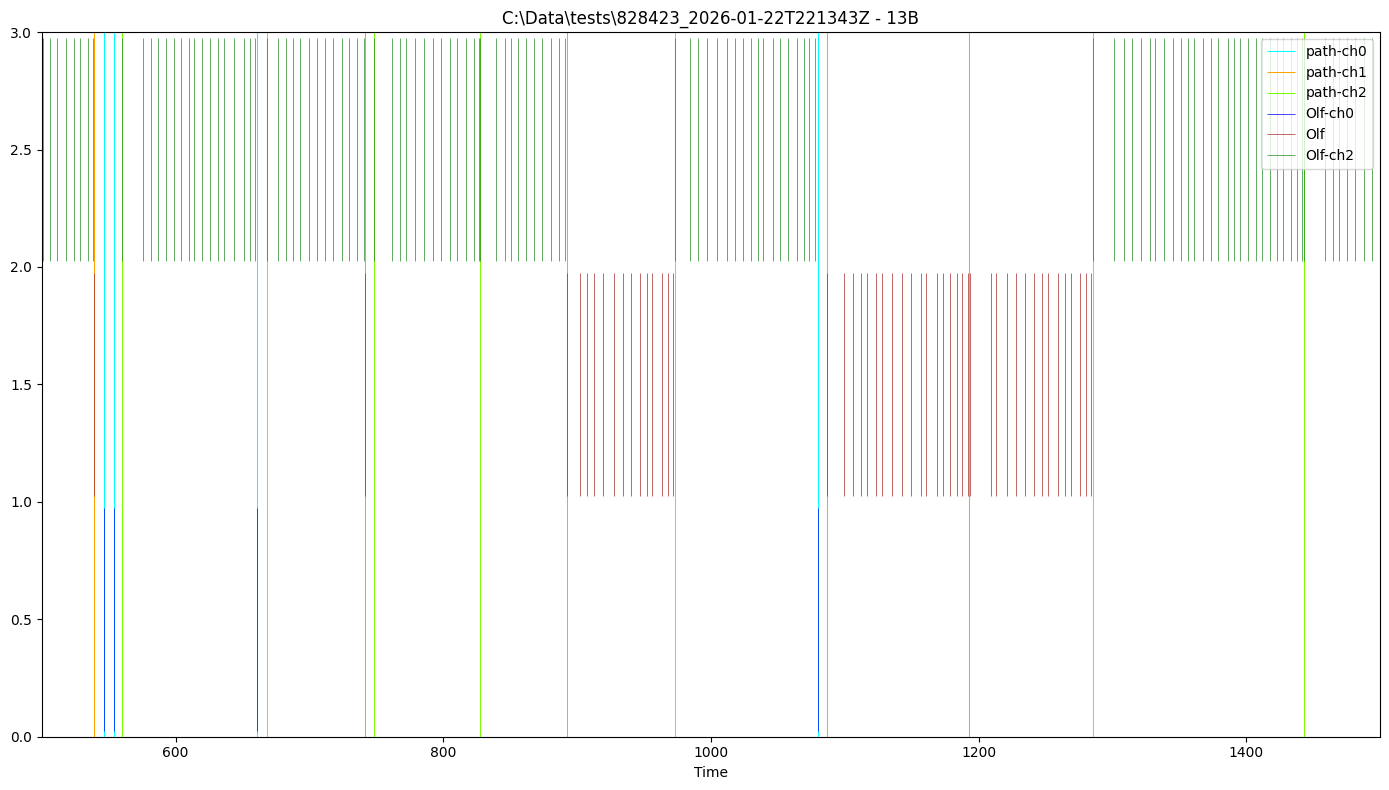

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          20.0      20.0          1.0     0.014046    0.012991     0.007392   
1         158.0     158.0          1.0     0.959767    1.865605     0.003392   
2         451.0     451.0          1.0     0.291674    1.246635     0.003392   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            20.0     1.000000     0.018648    0.014081       0.0104  
1           158.0     1.000000    19.409710   17.851498       0.0104  
2           443.0     0.982262    34.589234   23.311117       0.0104  


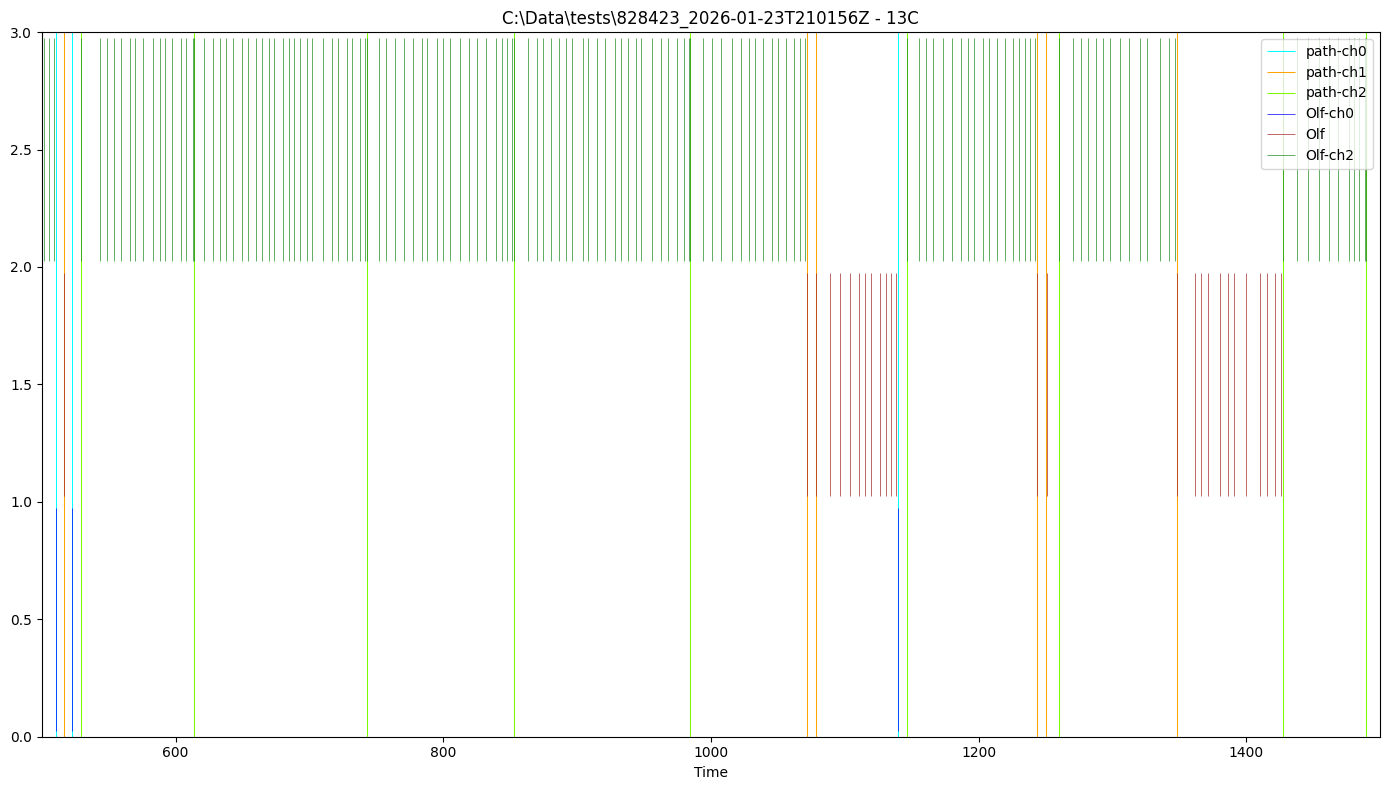

Loaded rig info: Computer - DT300043, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          15.0      15.0     1.000000     0.012192    0.006050     0.007872   
1         121.0     121.0     1.000000     4.204716    5.440946     0.004864   
2         270.0     269.0     0.996296     1.504086    3.902689     0.001856   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            15.0          1.0     0.019260    0.010561     0.009856  
1           121.0          1.0    14.945776   22.515431     0.008864  
2           270.0          1.0    41.561066   34.325367     0.009856  


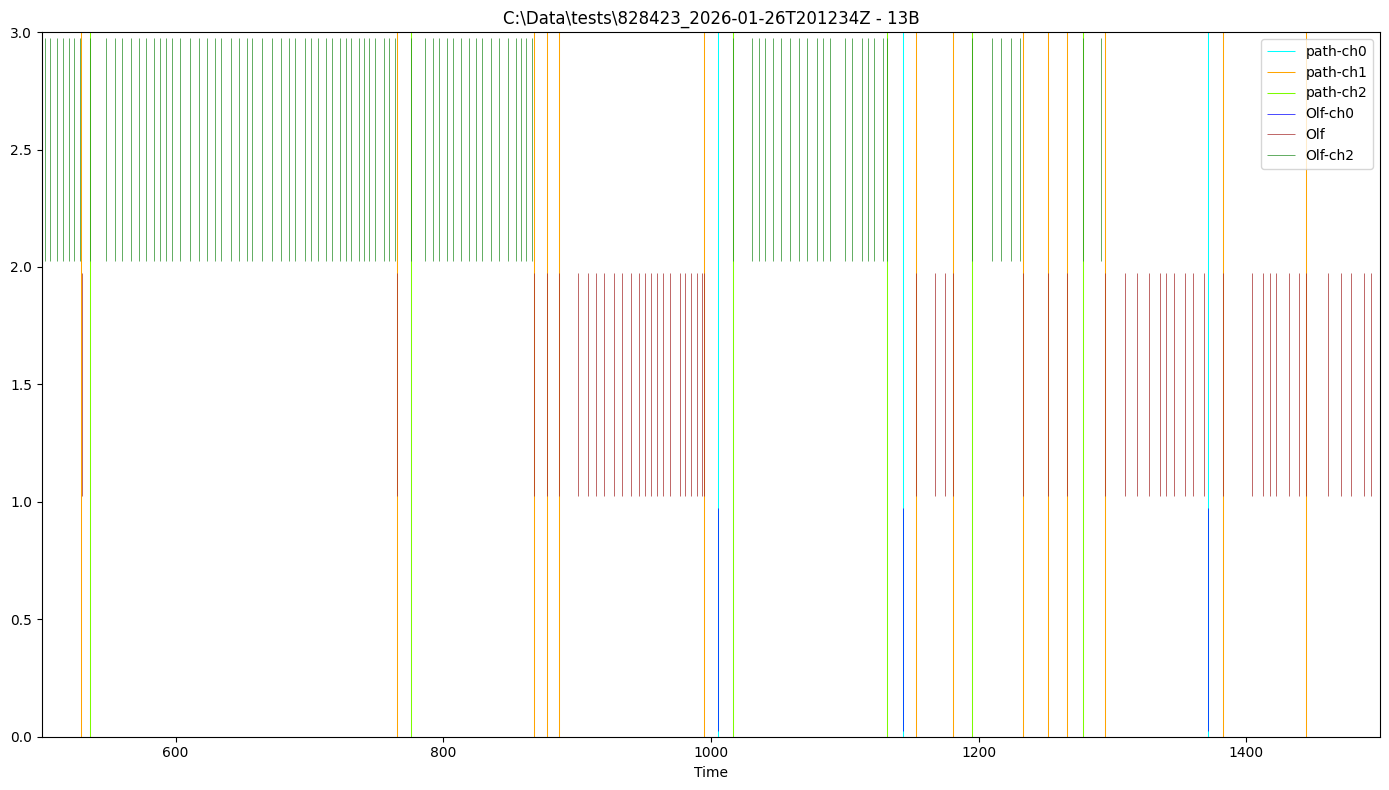

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           3.0       3.0          1.0     0.049941    0.046756     0.006944   
1         292.0     292.0          1.0     0.186273    1.039267     0.002944   
2         390.0     390.0          1.0     0.070437    0.535404     0.003936   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             3.0     1.000000     0.141952    0.161154     0.010944  
1           274.0     0.938356    50.650270   43.744701     0.009952  
2           255.0     0.653846   109.017529   73.351261     0.010912  


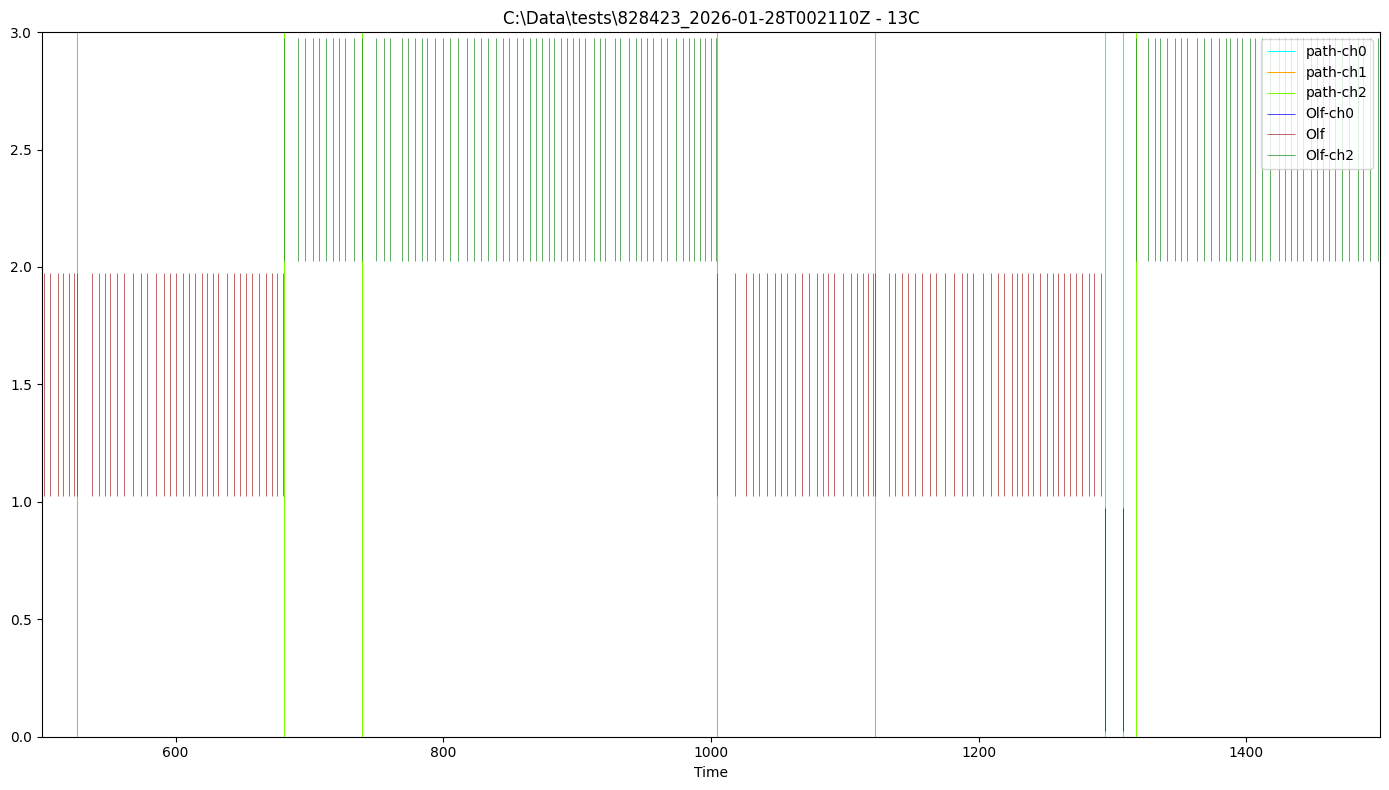

Loaded rig info: Computer - DT300043, Rig - 13A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          19.0      19.0          1.0     3.726796    1.793488     6.319104   
1         106.0     106.0          1.0     3.855628    4.757775     0.027904   
2         306.0     306.0          1.0     2.424385    3.465618     0.648896   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            18.0     0.947368    25.822363   23.926991     3.067104  
1           106.0     1.000000    55.224504   48.794718     6.334112  
2           306.0     1.000000    50.889697   42.116120     6.288192  


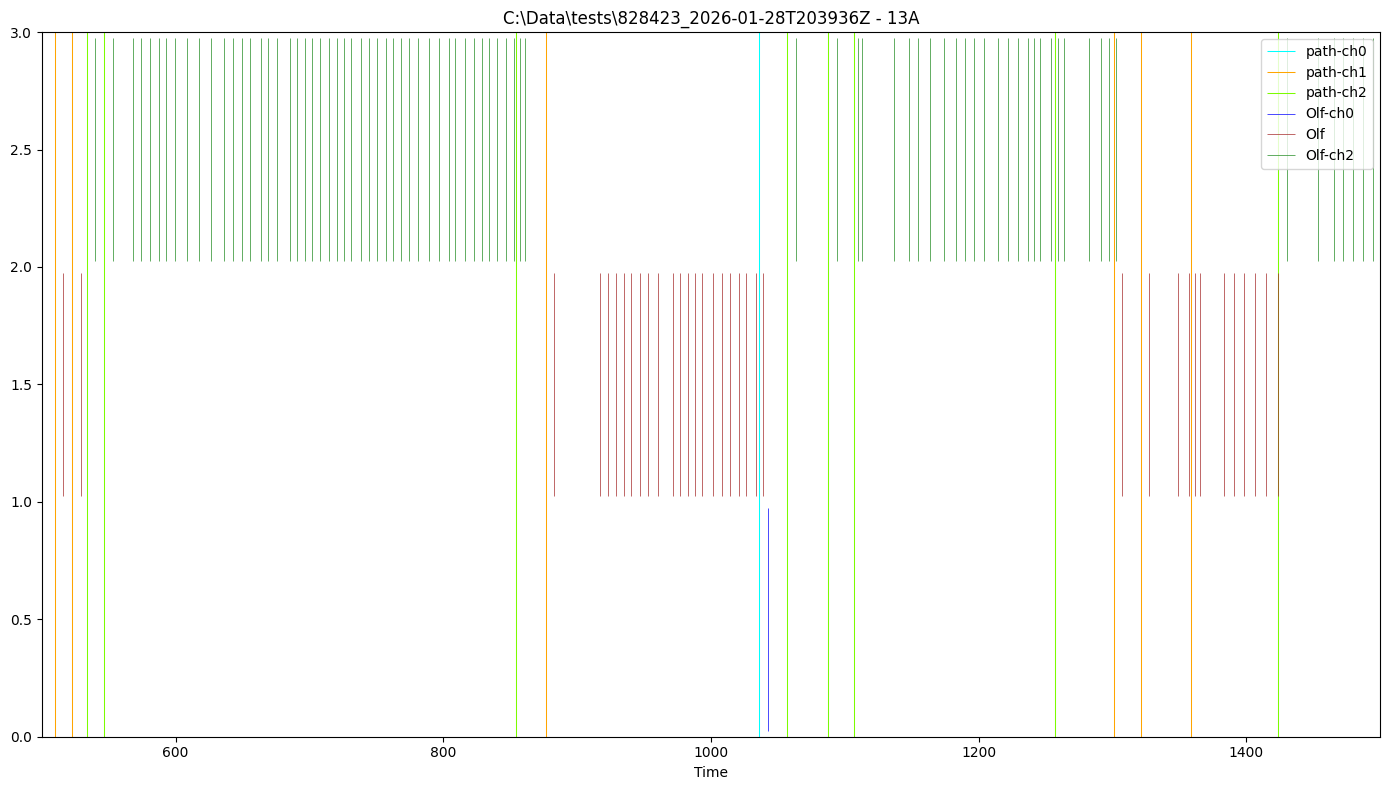

Loaded rig info: Computer - DT300043, Rig - 13A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           5.0       5.0     1.000000     2.312717    1.853470     0.314560   
1         141.0     140.0     0.992908     1.687253    1.963297     0.724448   
2         333.0     331.0     0.993994     2.220646    2.149142     0.948448   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             4.0     0.800000    12.929944   10.150108     7.051456  
1           129.0     0.914894   186.480537  161.539493     0.411552  
2           314.0     0.942943   245.927811  196.115041     0.705472  


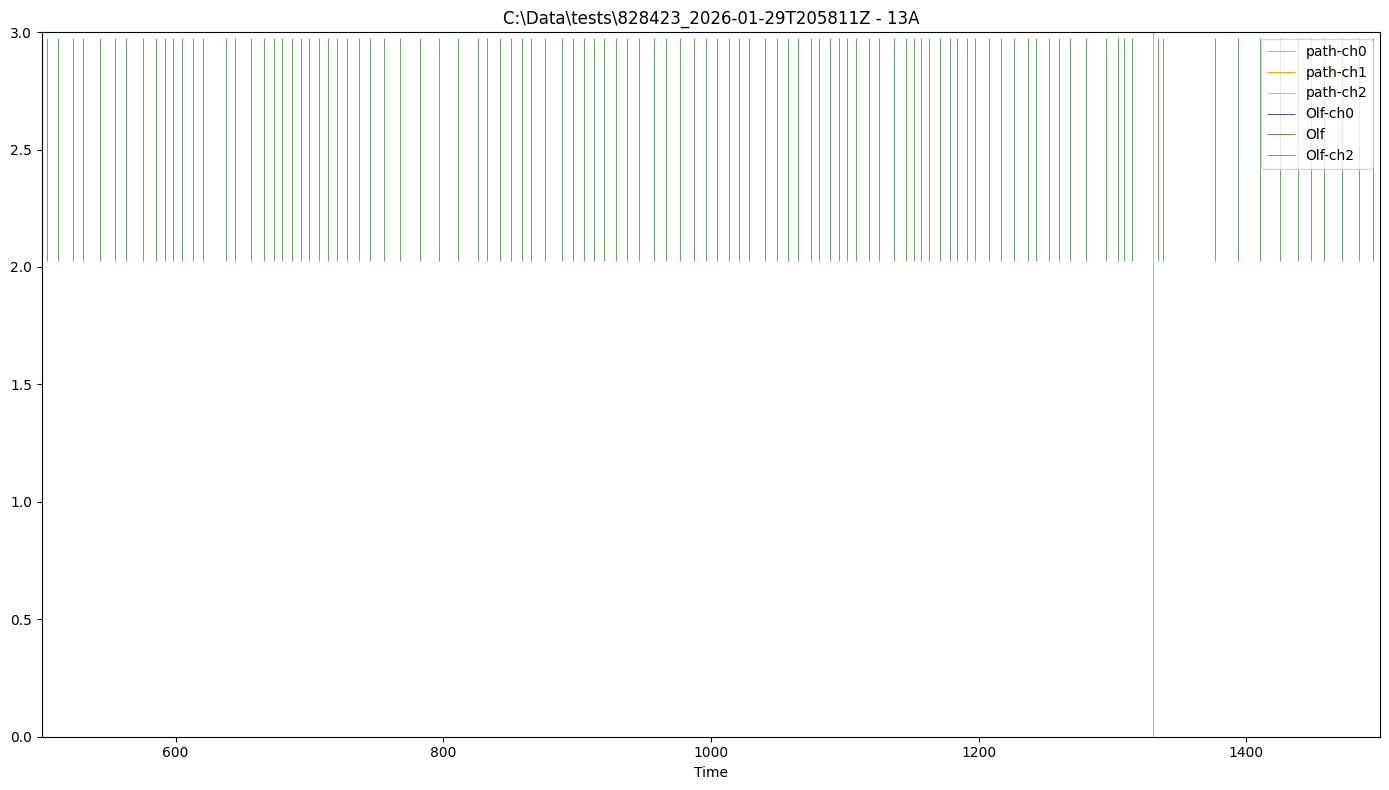

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           2.0       2.0          1.0     0.143584    0.135488     0.008096   
1         259.0     259.0          1.0     0.302486    1.881650     0.002080   
2         313.0     313.0          1.0     0.202131    1.460842     0.002080   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             2.0     1.000000     0.366576    0.356496     0.010080  
1           240.0     0.926641   104.367862   84.869674     0.009088  
2           272.0     0.869010   165.061868  109.947330     0.010080  


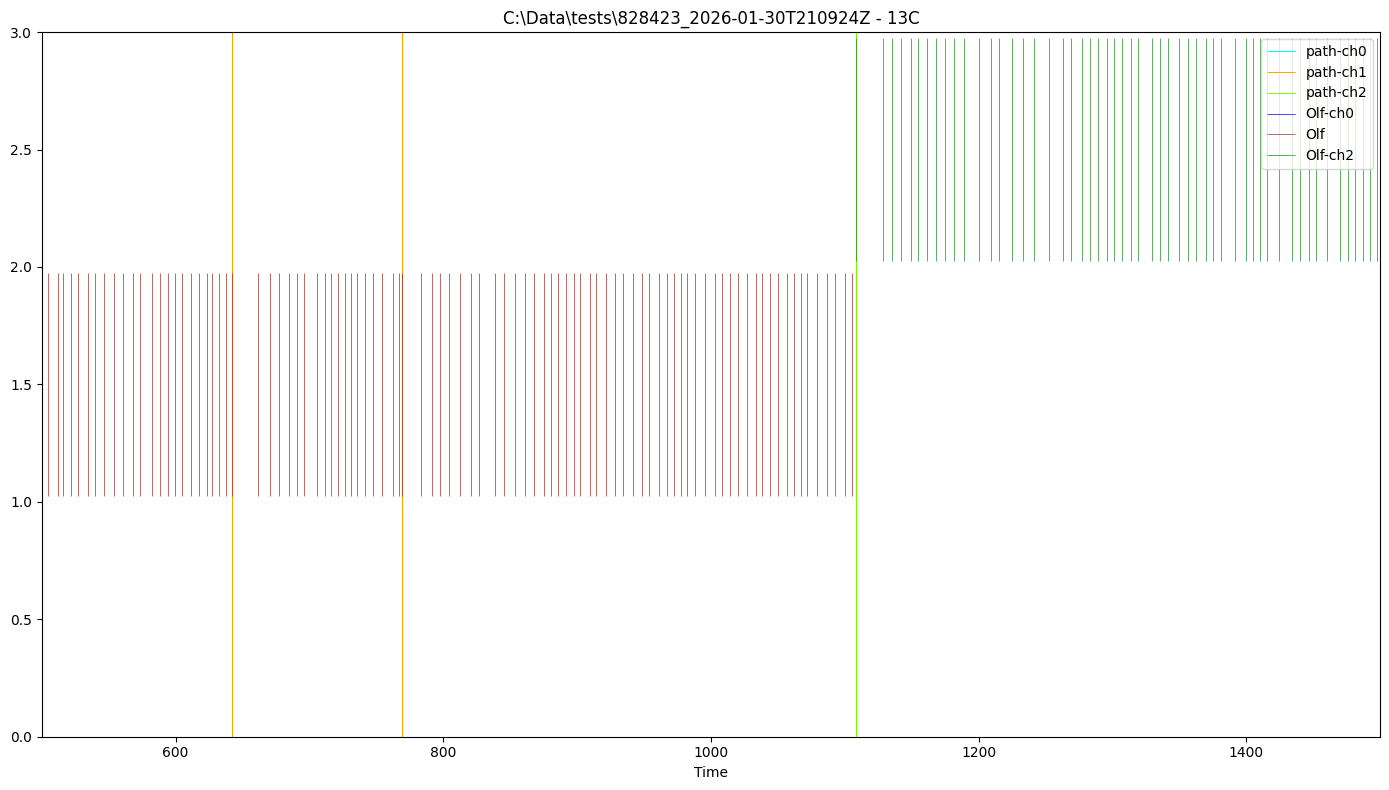

Loaded rig info: Computer - DT300562, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
1         156.0     156.0          1.0     0.240618    2.111688     0.002848   
2         154.0     154.0          1.0     0.128033    1.131606     0.002848   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
1            16.0     0.102564    72.618928   41.017188     0.021856  
2            84.0     0.545455   242.177805  147.581782     0.371840  


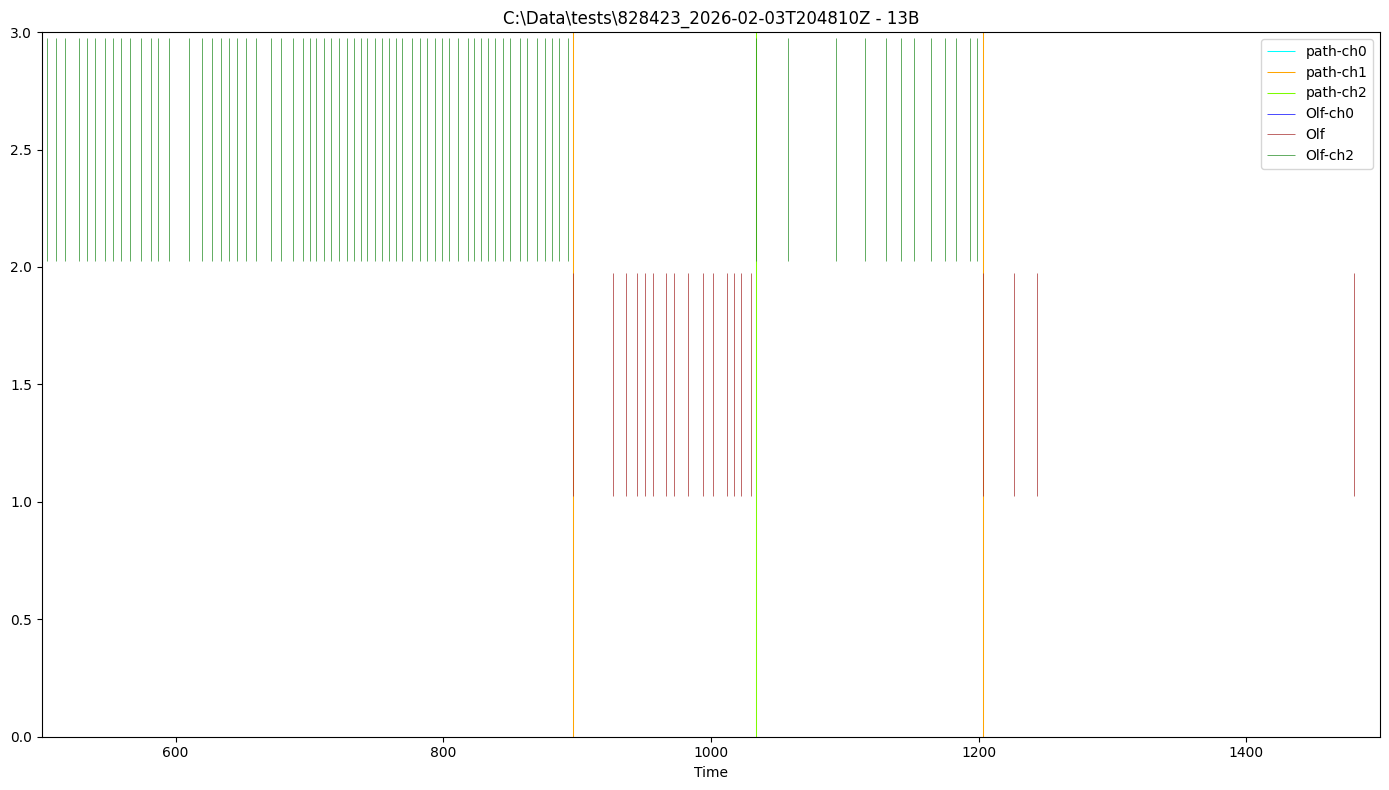

Loaded rig info: Computer - DT300577, Rig - 12A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
1         122.0     122.0          1.0     0.168018    1.802785      0.00336   
2          89.0      89.0          1.0     0.374284    3.473507      0.00336   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
1             1.0     0.008197     0.357376         0.0     0.357376  
2             1.0     0.011236     0.037344         0.0     0.037344  


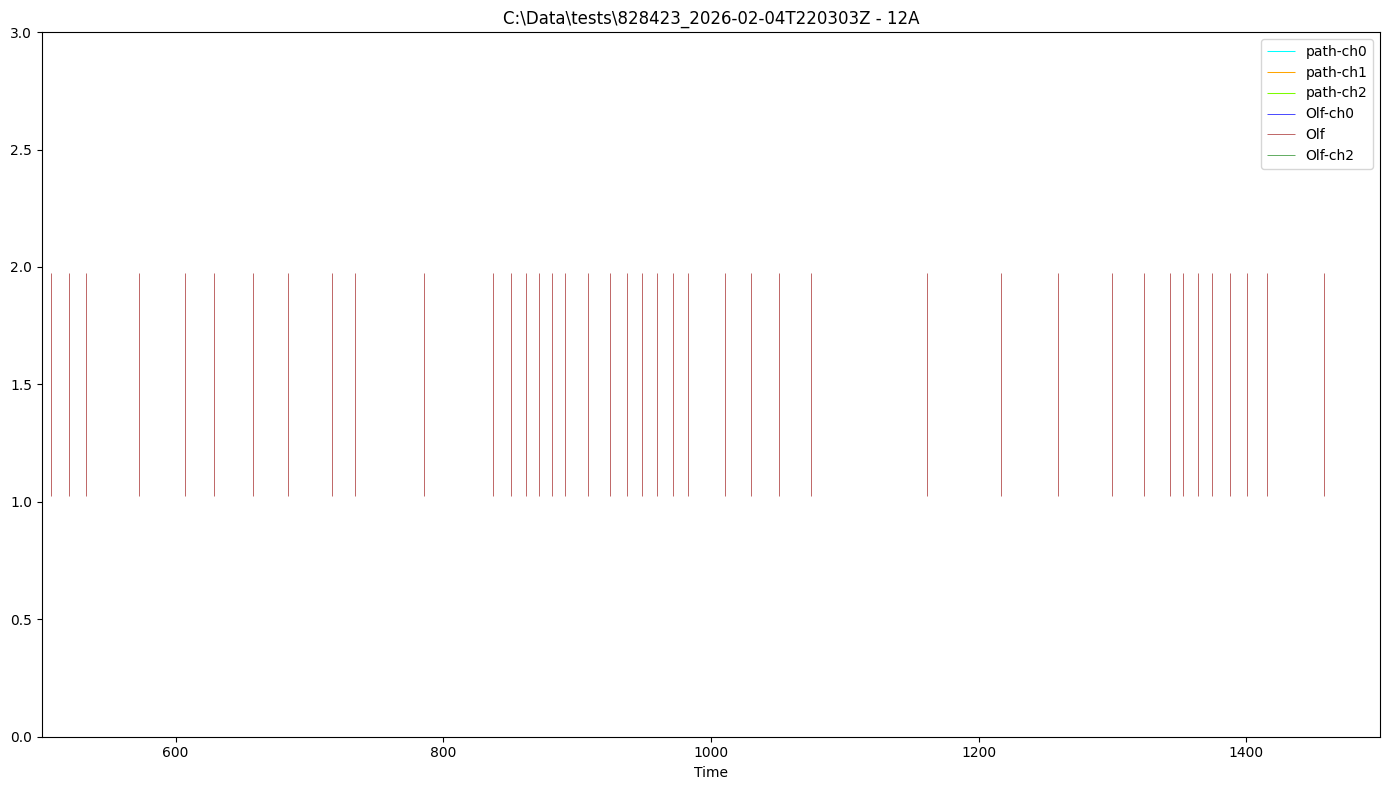

Loaded rig info: Computer - ABAIA, Rig - 4D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           2.0       2.0          1.0     0.012960    0.005984     0.006976   
1          81.0      81.0          1.0     1.018022    3.290712     0.002976   
2         346.0     346.0          1.0     0.291112    1.763374     0.002944   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             2.0      1.00000     0.020976    0.010000     0.010976  
1            81.0      1.00000    53.034357   37.814940     0.010944  
2           345.0      0.99711   317.238281  262.435009     0.014976  


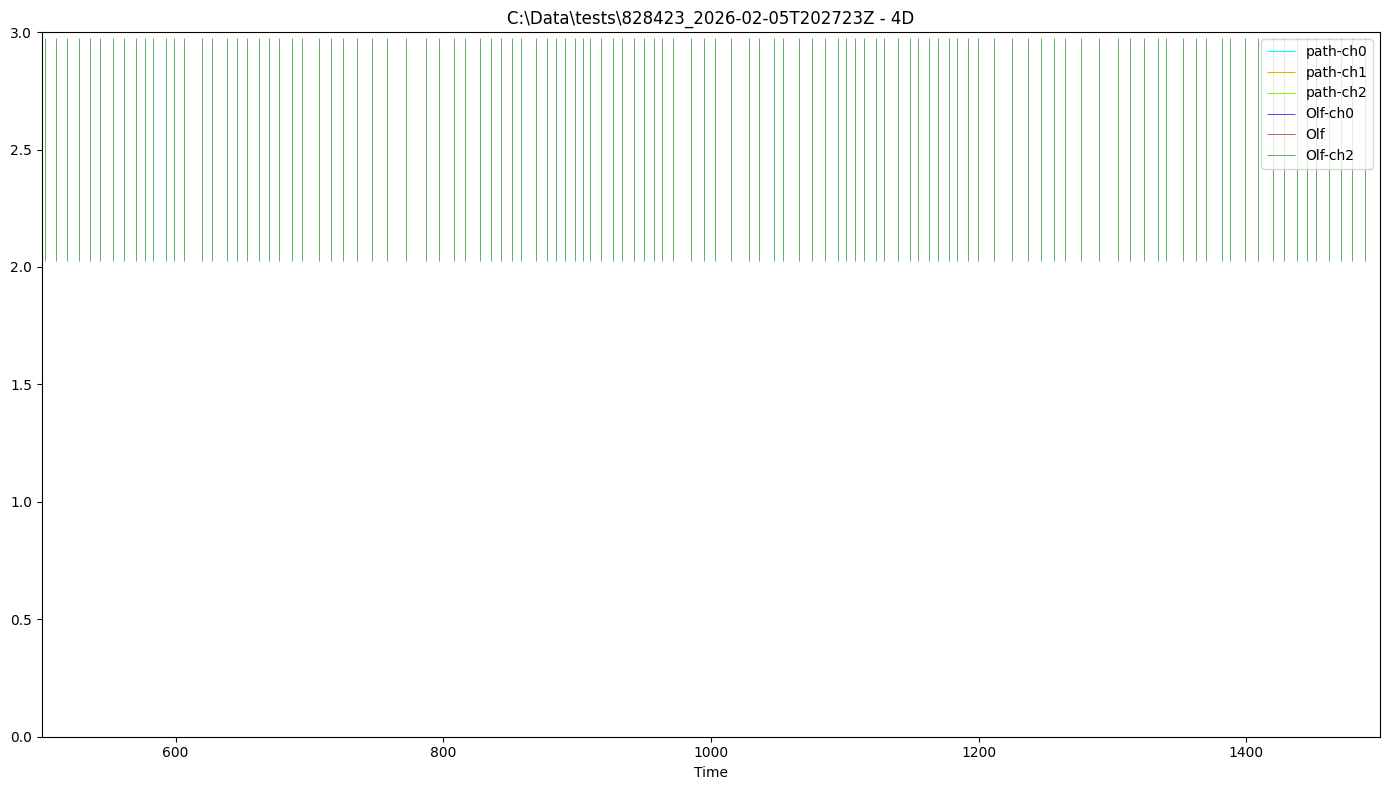

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           4.0       4.0          1.0     0.012632    0.004026     0.006880   
1         215.0     215.0          1.0     0.192930    1.004238     0.001888   
2         298.0     298.0          1.0     0.128859    0.888501     0.001888   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             4.0     1.000000     0.018632    0.006258     0.012864  
1           150.0     0.697674    59.500026   47.559300     0.016864  
2           245.0     0.822148    58.364827   41.097099     0.011904  


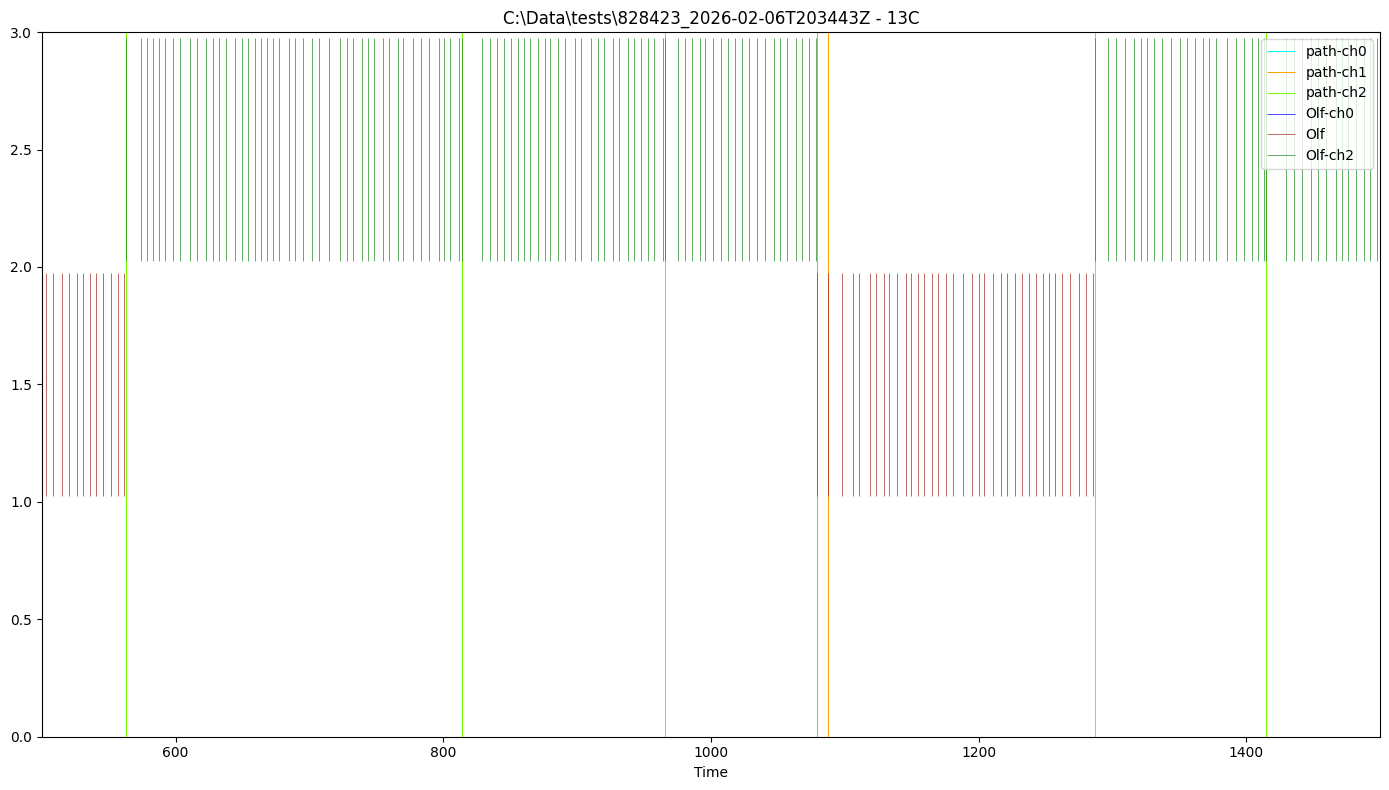

Loaded rig info: Computer - DT300539, Rig - 12C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          20.0      20.0     1.000000     0.012739    0.007667     0.007136   
1         193.0     192.0     0.994819     3.319378    3.744553     0.003136   
2         128.0     128.0     1.000000     4.583311    4.408316     0.003136   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            20.0          1.0     0.467238    1.950970     0.009120  
1           193.0          1.0    12.195567   21.537276     0.010144  
2           128.0          1.0     6.649346   13.757662     0.010144  


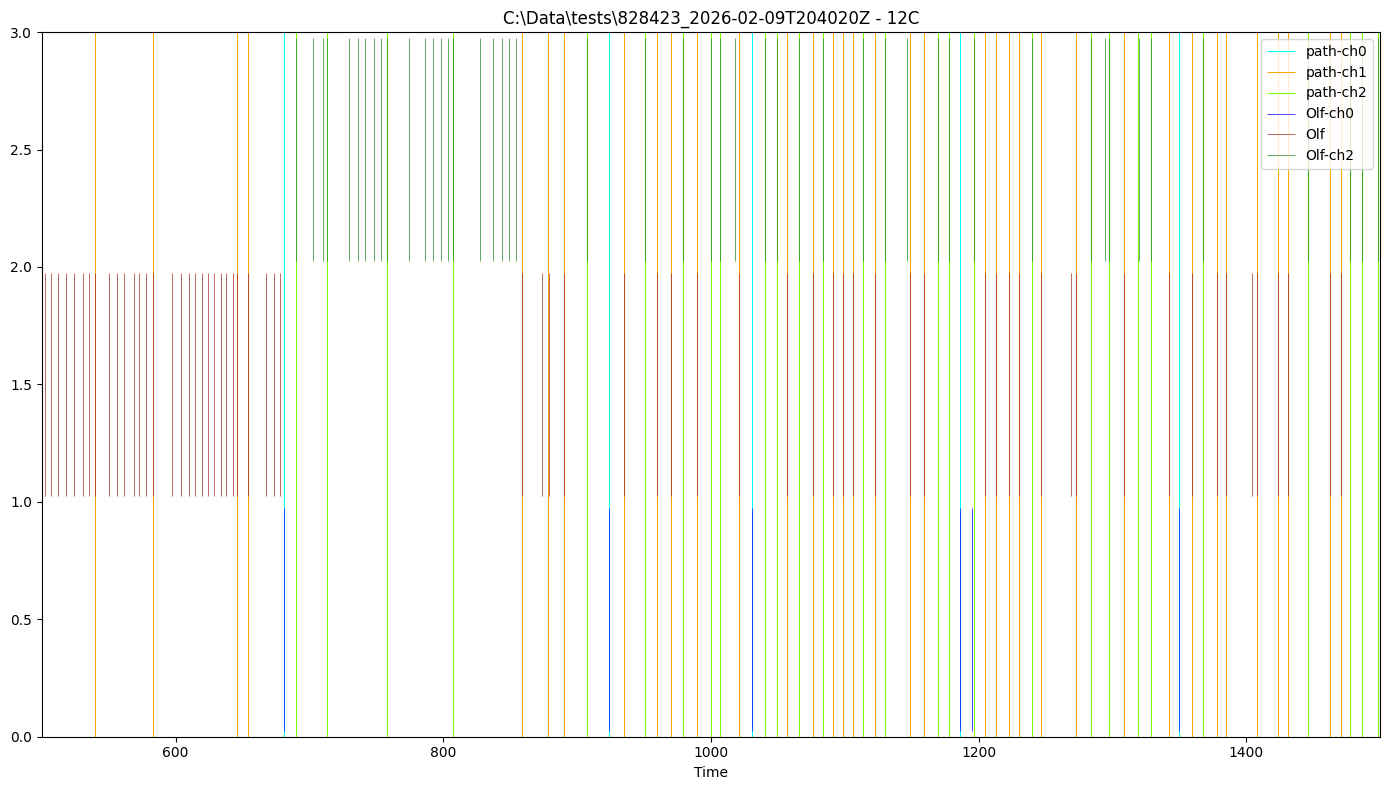

Loaded rig info: Computer - DT300562, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
1         398.0     398.0          1.0     0.077325    0.716129     0.002336   
2           5.0       5.0          1.0     3.524333    4.753047     0.002336   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
1           308.0     0.773869   300.026426  174.835982     0.013344  
2             3.0     0.600000     3.185995    4.445109     0.034336  


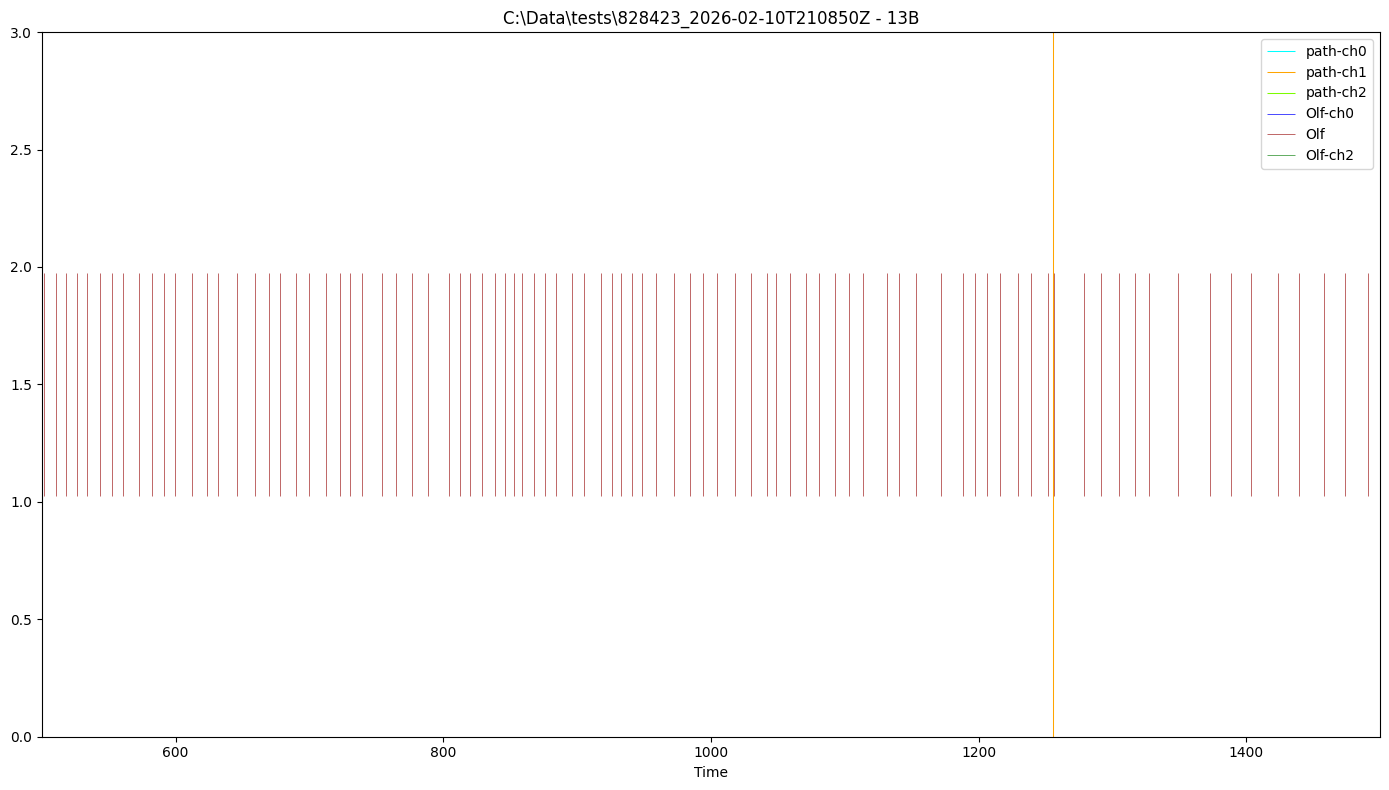

Loaded rig info: Computer - DT300043, Rig - 13A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           1.0       1.0     1.000000     2.316160    0.000000     2.316160   
1         306.0     301.0     0.983660     1.969812    1.939289     0.085184   
2         289.0     286.0     0.989619     1.834299    2.208719     0.090176   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             1.0     1.000000    16.869824    0.000000    16.869824  
1           306.0     1.000000   141.694144  132.938048    16.561824  
2           270.0     0.934256    72.091557   54.065476    16.553824  


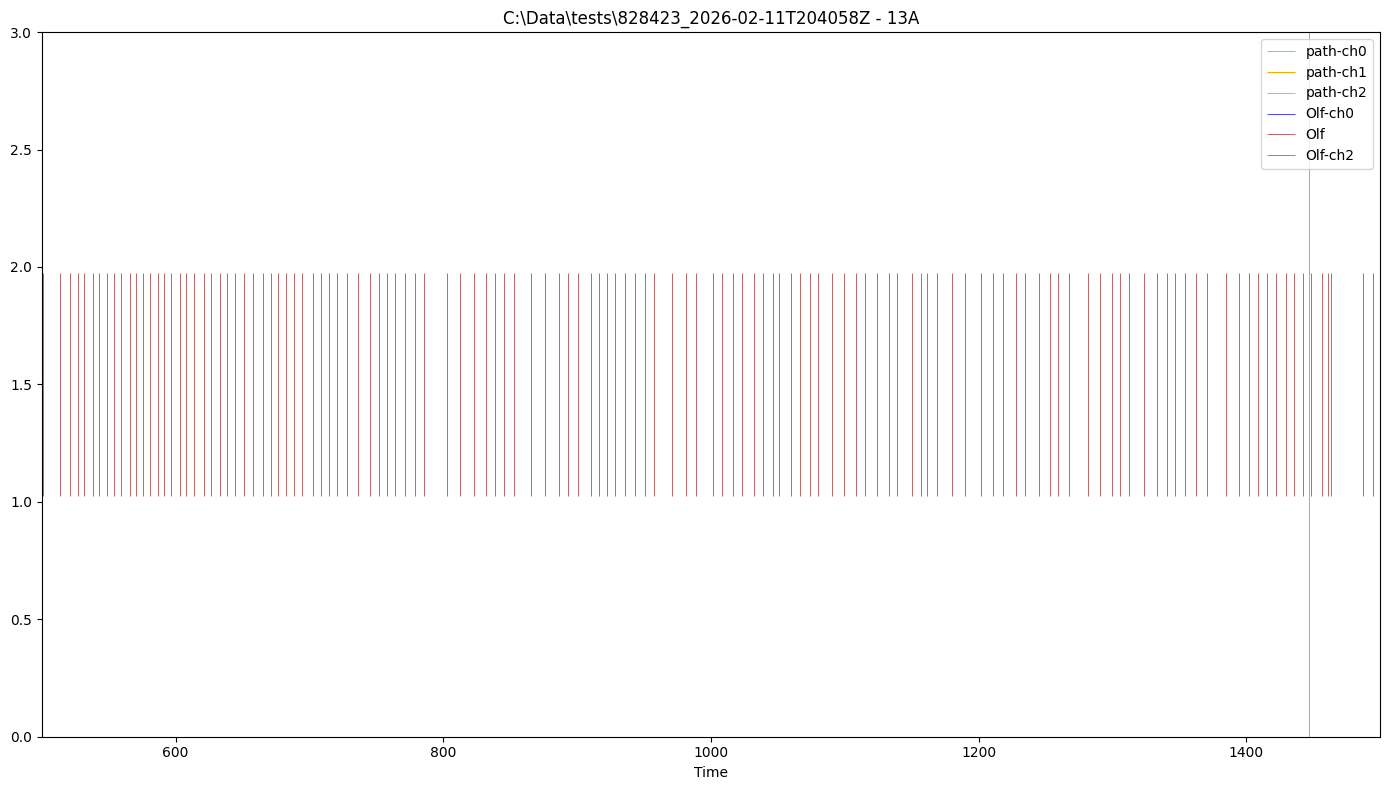

Loaded rig info: Computer - DT300539, Rig - 12C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          26.0      26.0          1.0     0.018578    0.021455     0.006912   
1         198.0     198.0          1.0     3.291407    3.561017     0.001920   
2         207.0     207.0          1.0     3.449218    4.245962     0.001920   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            26.0          1.0     0.626741    2.262821     0.008928  
1           198.0          1.0    16.833708   29.230332     0.008928  
2           207.0          1.0    17.175886   28.476507     0.008928  


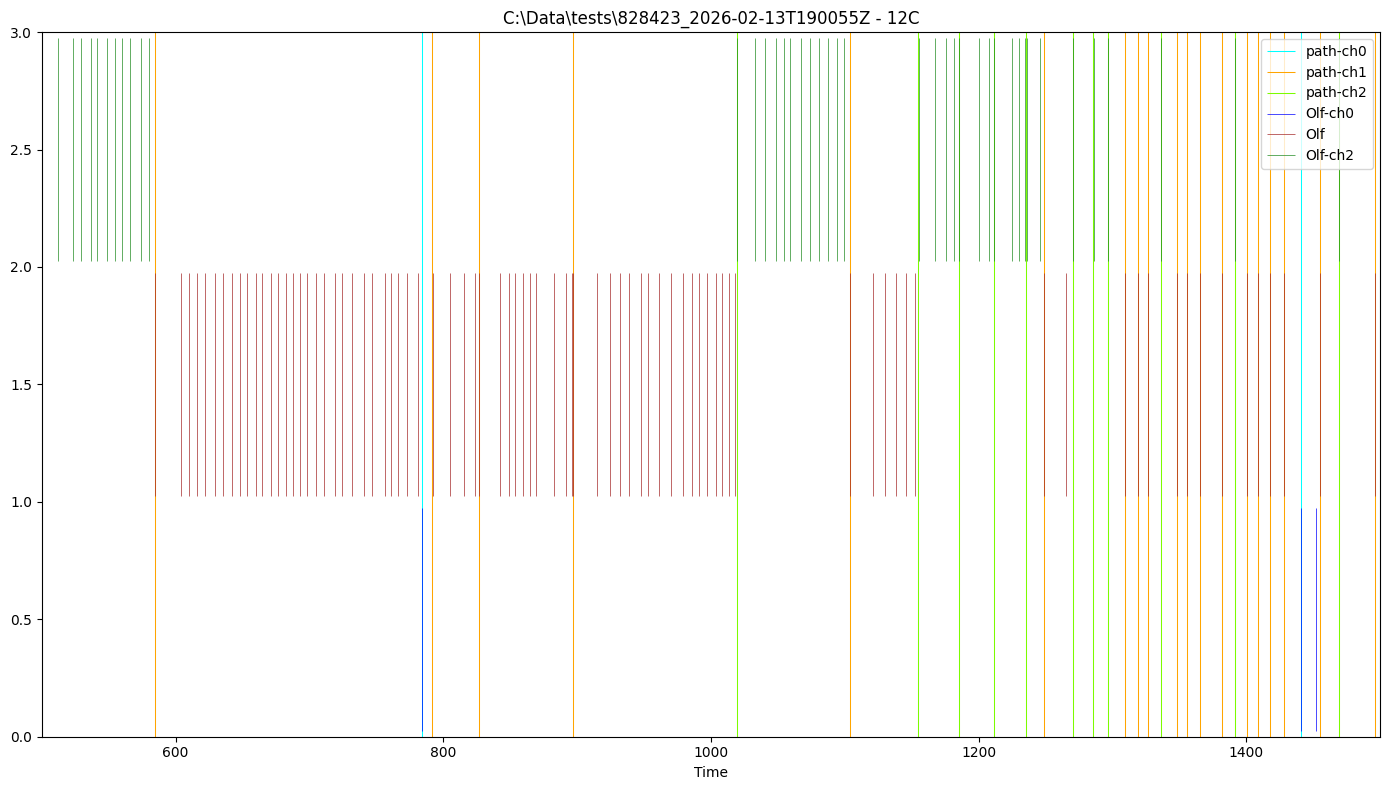

Loaded rig info: Computer - DT300577, Rig - 12A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
2         563.0     563.0          1.0     0.024365    0.313681     0.002144   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
2           267.0     0.474245  1102.563815  669.699265     0.051168  


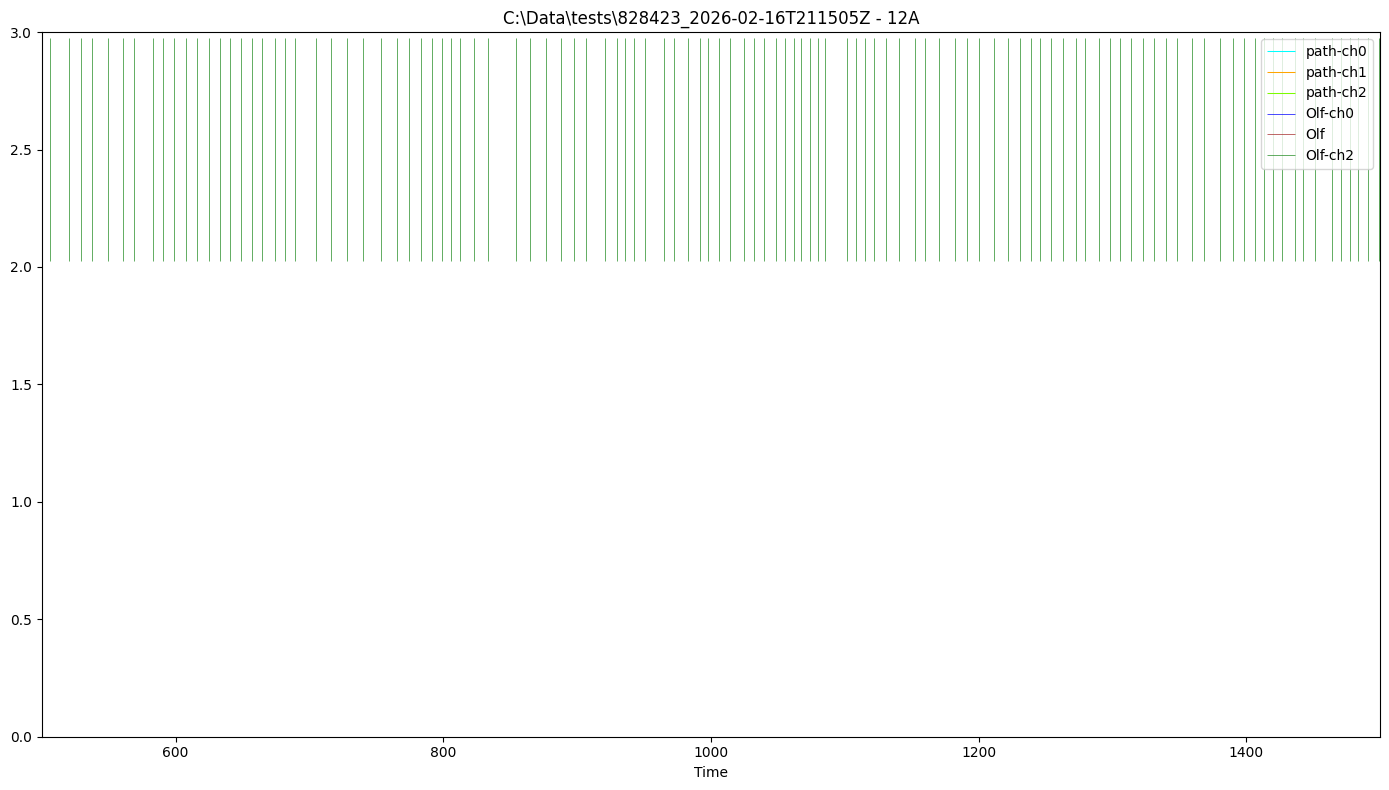

Loaded rig info: Computer - YACUMAMA, Rig - 4C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          11.0      11.0     1.000000     0.015491    0.006499     0.015136   
1         150.0     149.0     0.993333     2.983508    4.454082     0.003136   
2         239.0     239.0     1.000000     1.888500    3.777245     0.003136   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            11.0          1.0     1.162036    3.603463     0.010112  
1           150.0          1.0    19.273940   22.537552     0.010112  
2           239.0          1.0    26.750913   25.186951     0.010112  


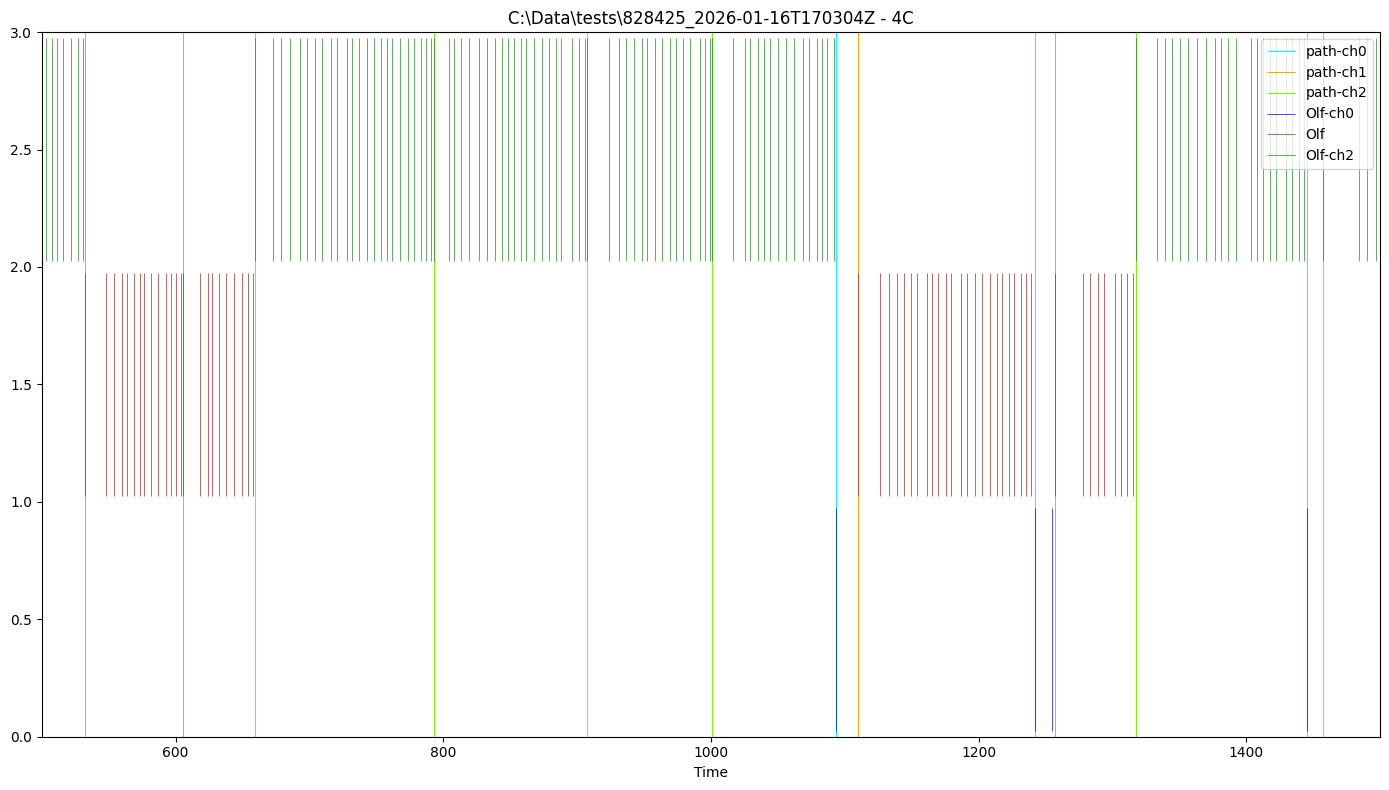

Loaded rig info: Computer - DT300043, Rig - 13A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          18.0      18.0     1.000000     0.493575    0.015116     0.511296   
1         254.0     253.0     0.996063     1.617406    2.979225     0.475296   
2         260.0     260.0     1.000000     1.494492    2.761297     0.494304   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            18.0     1.000000     2.239019    4.975921     0.481280  
1           250.0     0.984252    20.336541   17.643901     0.474304  
2           232.0     0.892308    26.824997   24.289834     0.495296  


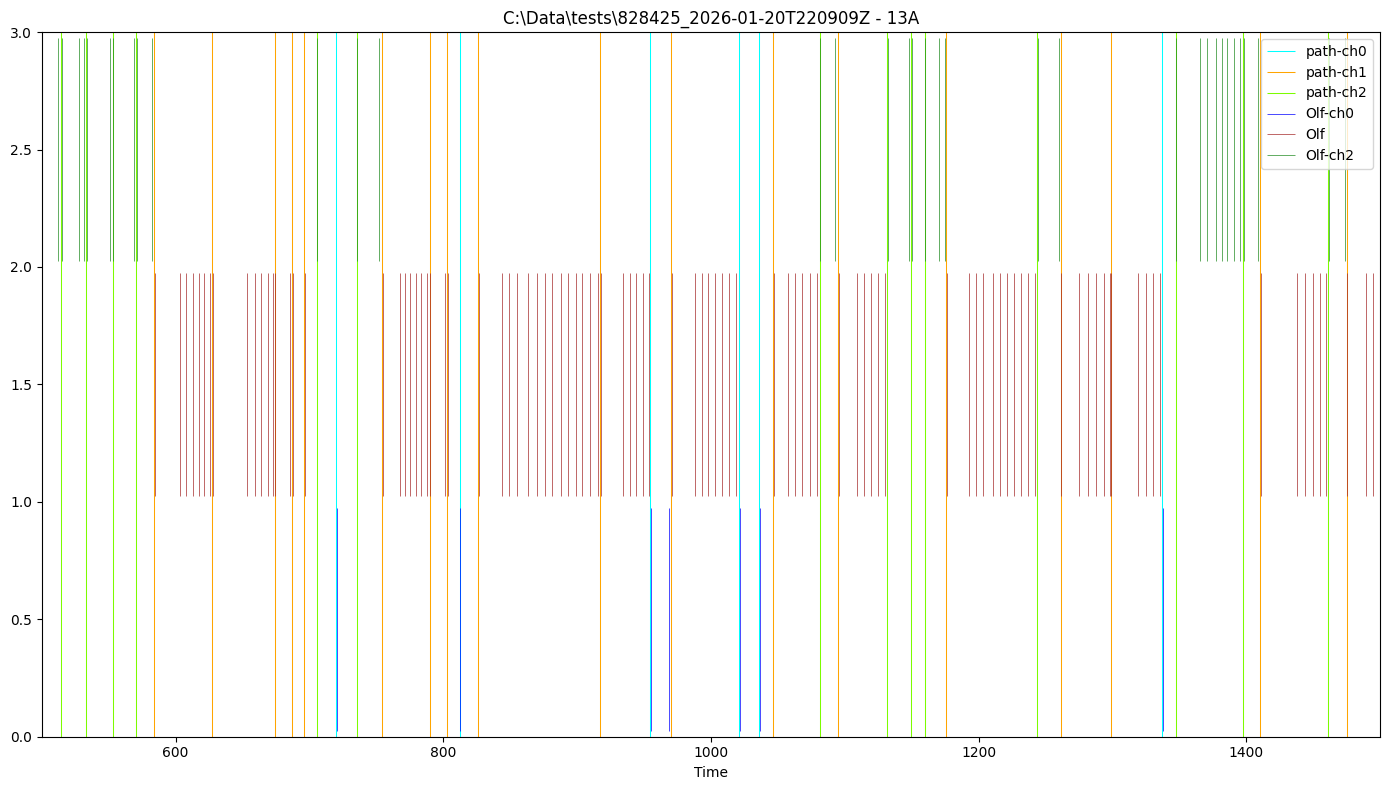

Loaded rig info: Computer - DT300043, Rig - 13A
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          14.0      14.0     1.000000     2.517646    0.374500     1.224288   
1         162.0     161.0     0.993827     4.799957    3.921021     2.610688   
2         268.0     268.0     1.000000     3.965306    3.513962     2.623712   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            14.0          1.0     7.072843   11.124770     2.619680  
1           162.0          1.0     9.523789   10.648629     2.649696  
2           268.0          1.0    17.029678   20.102354     2.664704  


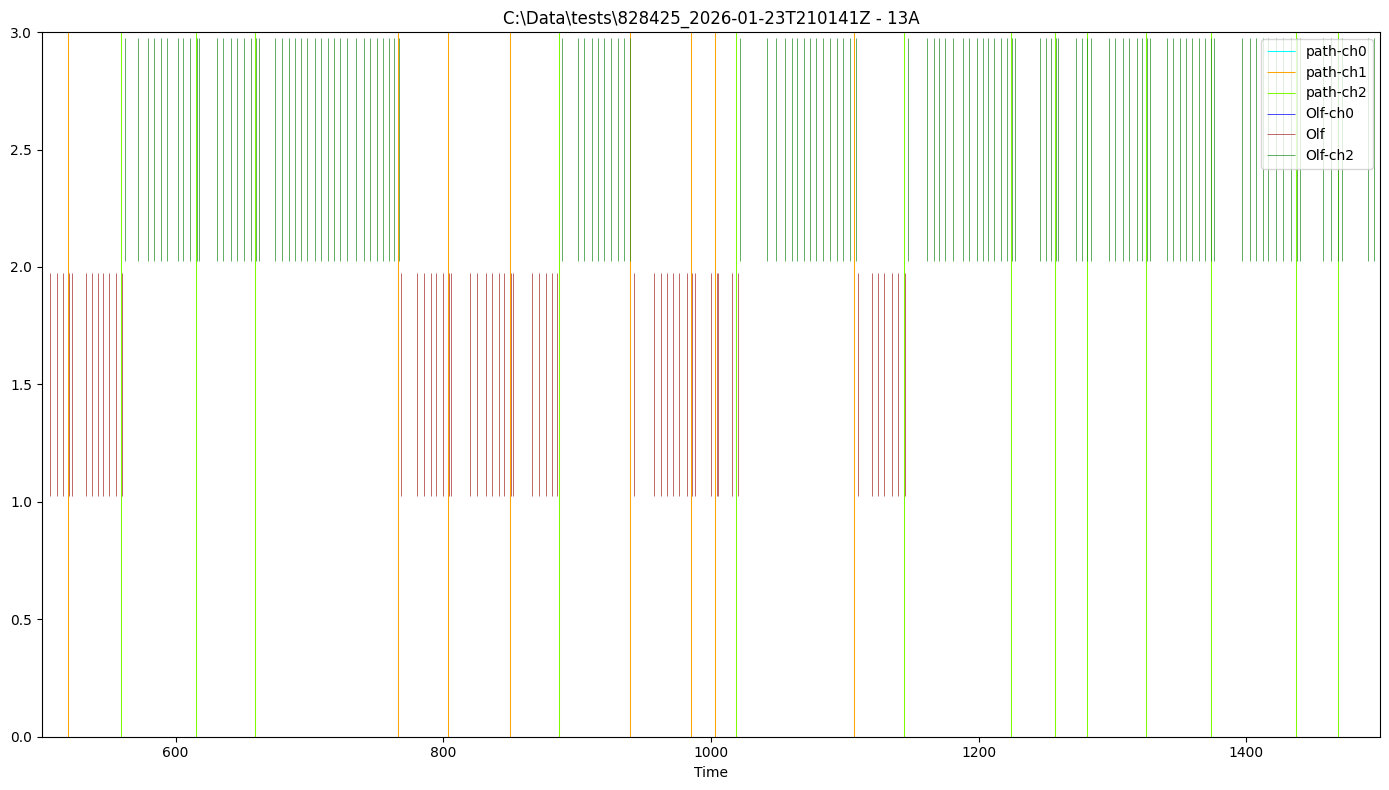

Loaded rig info: Computer - DT300562, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          22.0      22.0          1.0     0.009494    0.005745     0.009088   
1         151.0     151.0          1.0     4.406435    4.310704     0.002080   
2         255.0     255.0          1.0     2.664105    4.070921     0.002080   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            22.0          1.0     2.176400    5.583397     0.009088  
1           151.0          1.0     4.854903    8.415529     0.010080  
2           255.0          1.0    19.632434   27.202092     0.010080  


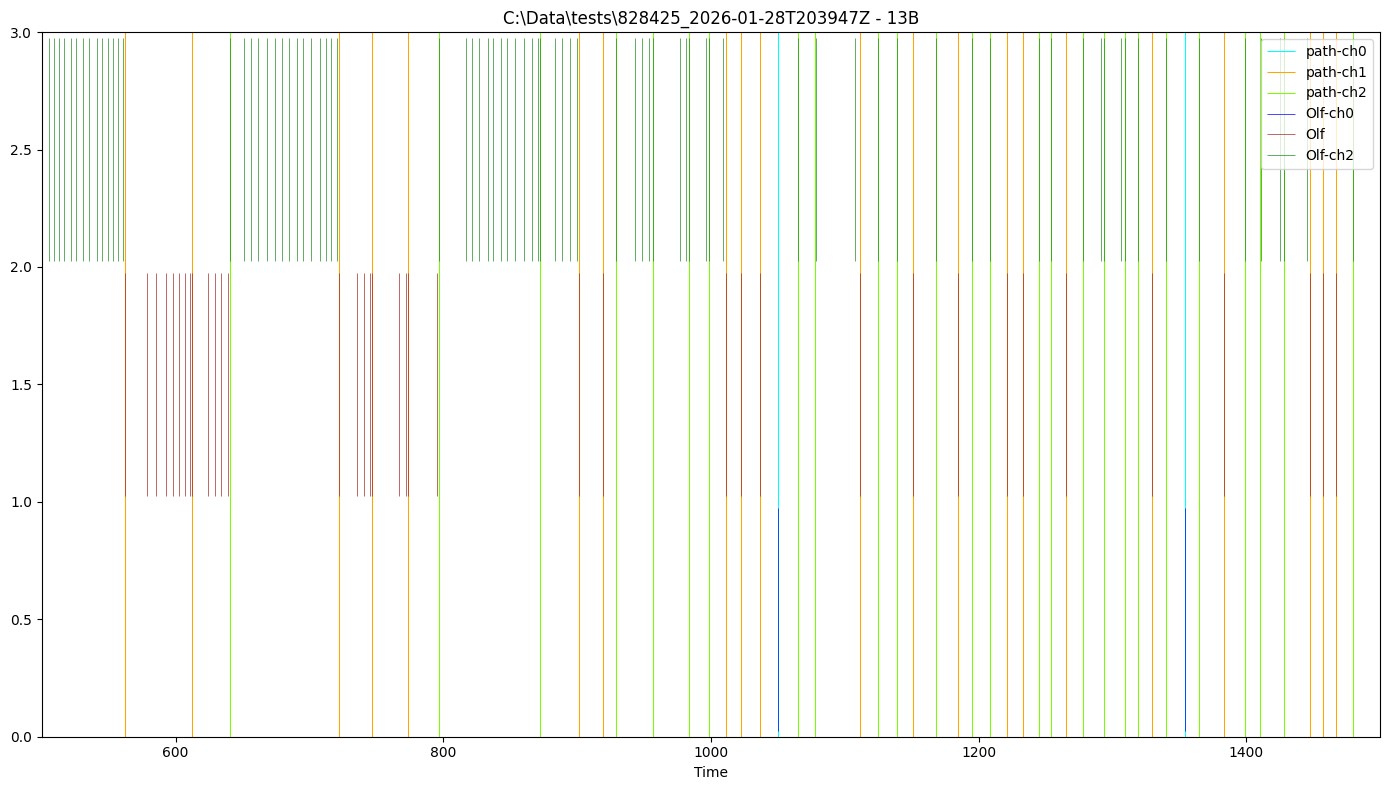

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          16.0      16.0          1.0     0.011880    0.006817     0.007520   
1         193.0     193.0          1.0     2.128253    3.186180     0.002496   
2         334.0     334.0          1.0     1.300357    2.742967     0.002496   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            16.0          1.0     0.020376    0.010112     0.009504  
1           193.0          1.0     6.222701    7.901898     0.010496  
2           334.0          1.0    13.663716   13.997616     0.009504  


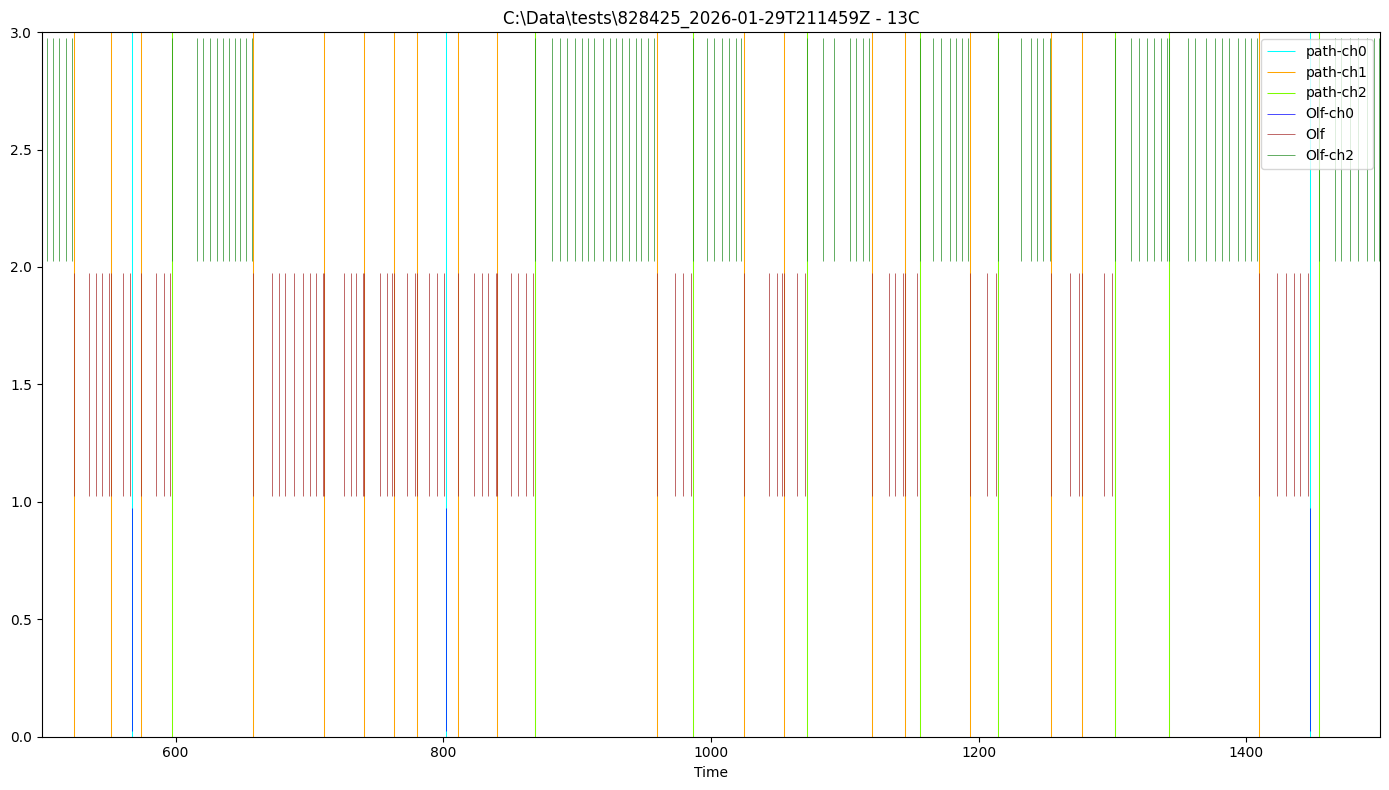

Loaded rig info: Computer - DT300562, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          31.0      31.0          1.0     0.015656    0.011425     0.006912   
1         200.0     200.0          1.0     3.292015    4.296867     0.001920   
2         259.0     259.0          1.0     2.281574    3.445541     0.002912   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            31.0          1.0     0.022237    0.013171      0.00992  
1           200.0          1.0     5.498488    8.640956      0.00992  
2           259.0          1.0    21.844619   38.100112      0.00992  


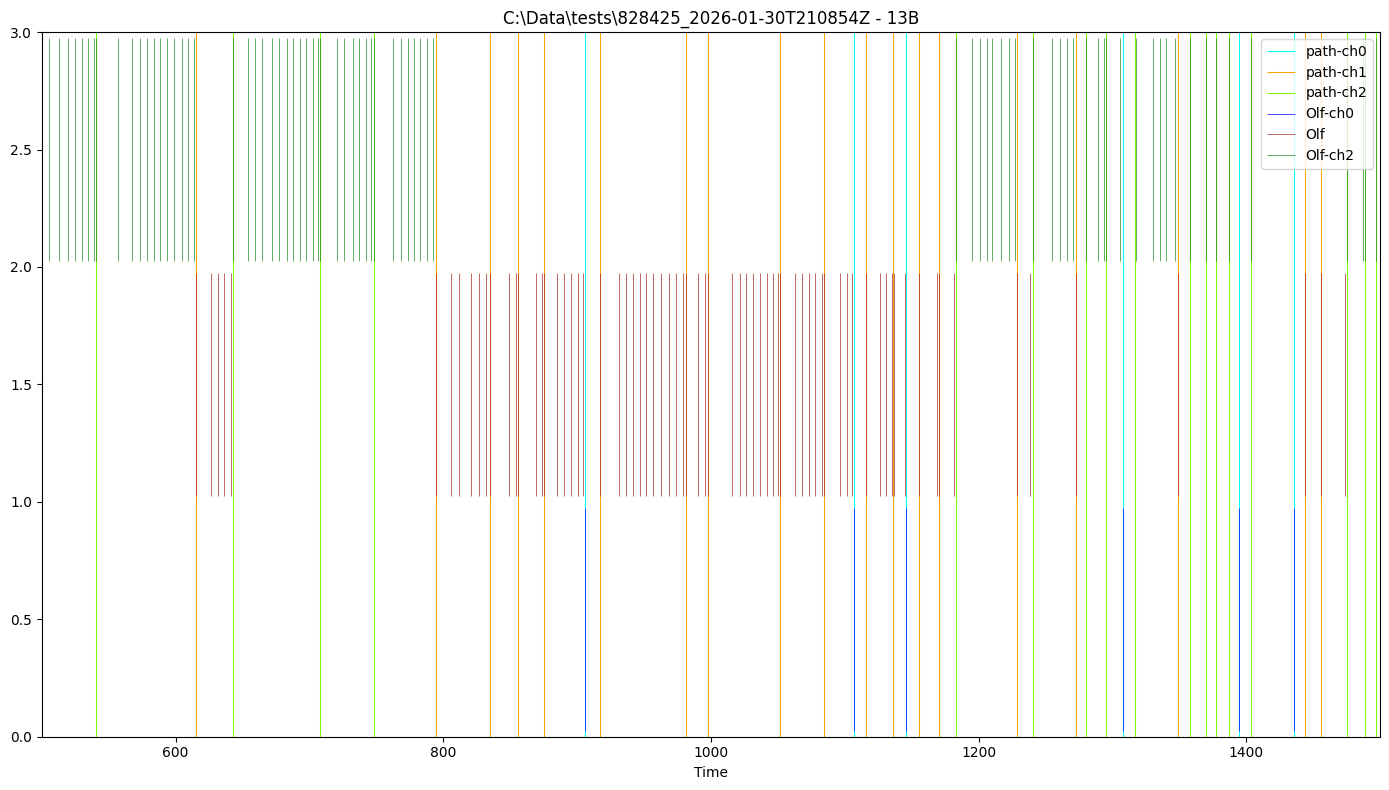

Loaded rig info: Computer - DT300539, Rig - 12C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          23.0      23.0          1.0     0.015232    0.010350     0.006784   
1         177.0     177.0          1.0     4.669108    3.807400     0.002816   
2         214.0     214.0          1.0     3.581814    4.158667     0.001792   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            23.0          1.0     0.558534    2.525870     0.009792  
1           177.0          1.0     1.765841    5.013742     0.009792  
2           214.0          1.0     9.241706   13.461949     0.009792  


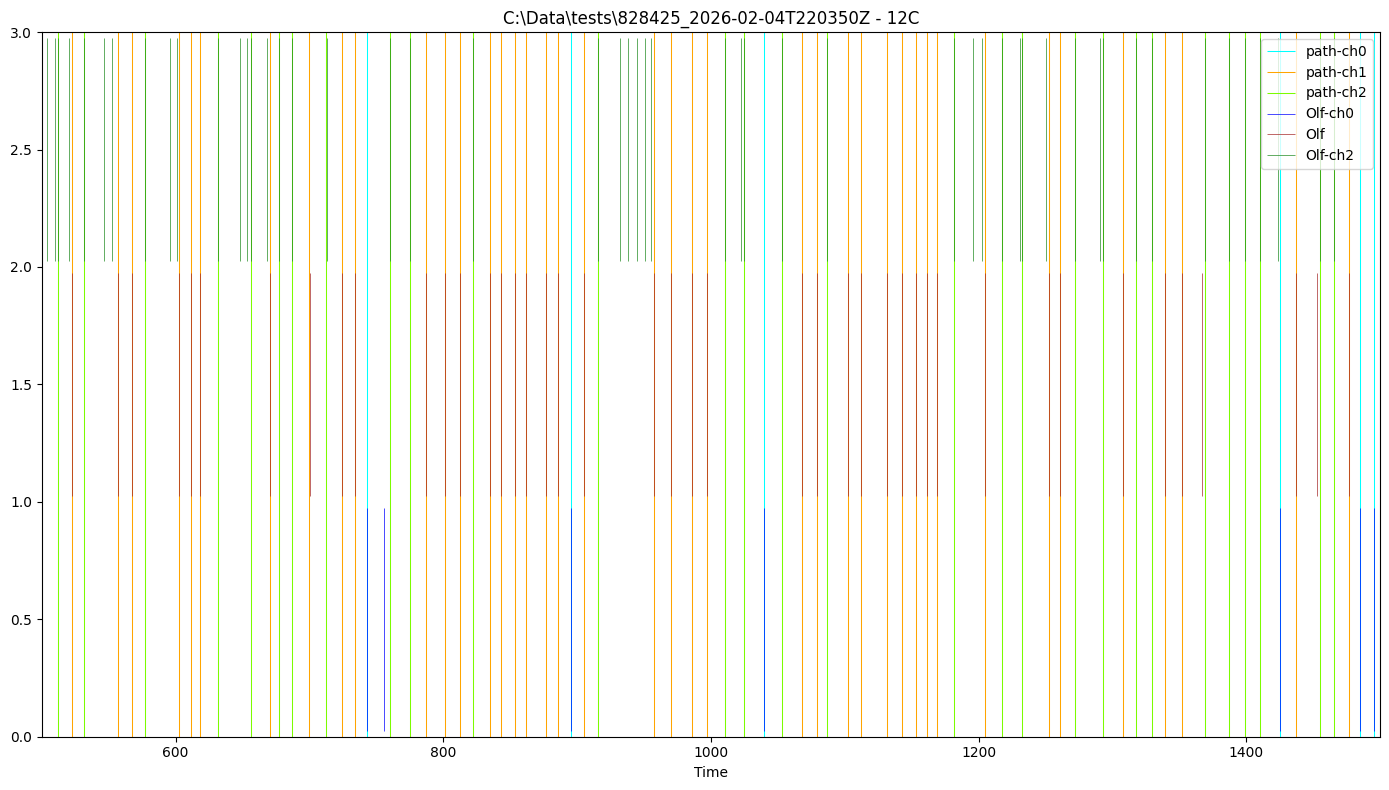

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          19.0      19.0      1.00000     0.016187    0.007306     0.007552   
1         143.0     143.0      1.00000     2.559897    3.443275     0.002560   
2         376.0     375.0      0.99734     1.032724    2.596577     0.003552   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            19.0          1.0     0.026605    0.014099     0.044544  
1           143.0          1.0     7.162494    8.858849     0.009568  
2           376.0          1.0    13.588843   11.198625     0.010560  


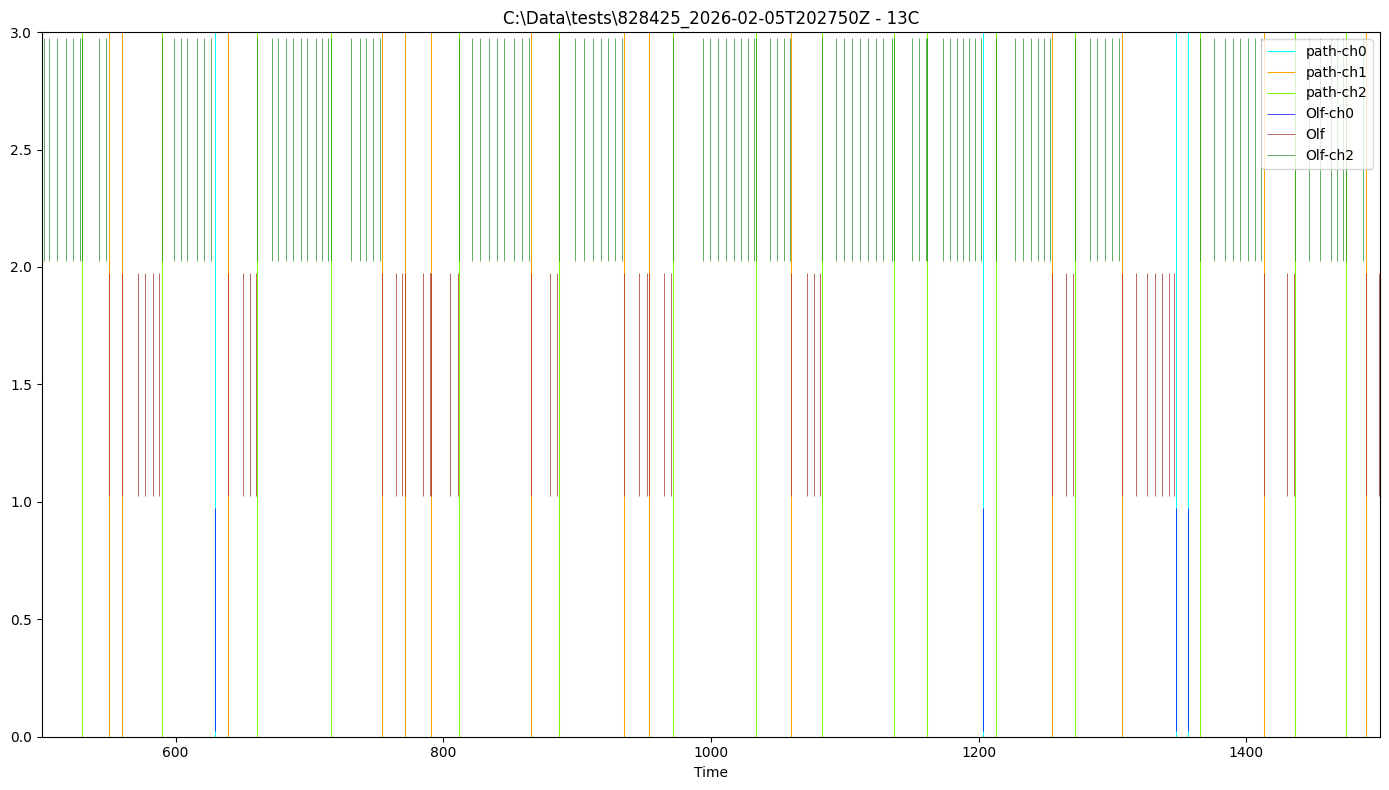

Loaded rig info: Computer - ABAIA, Rig - 4D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          18.0      18.0          1.0     0.013266    0.009295     0.006144   
1         163.0     163.0          1.0     3.276780    3.556791     0.003136   
2         311.0     311.0          1.0     1.436662    2.705159     0.003168   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            18.0      1.00000     0.022930    0.012792     0.009152  
1           161.0      0.98773     4.301846    7.638836     0.010176  
2           311.0      1.00000    17.079851   15.970314     0.010144  


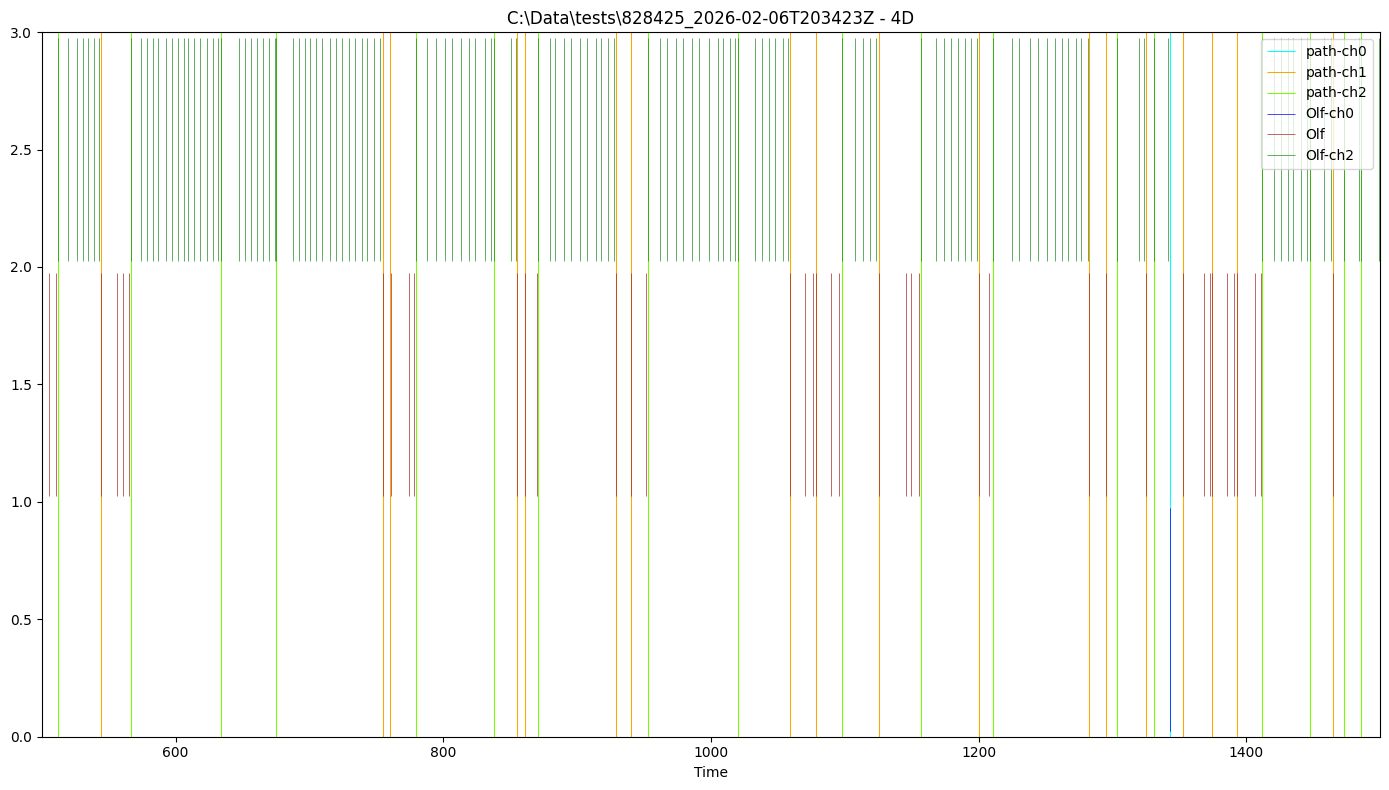

Loaded rig info: Computer - DT300562, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0           6.0       6.0          1.0     0.013621    0.008173     0.006944   
1         131.0     131.0          1.0     2.122205    3.594741     0.003936   
2         329.0     329.0          1.0     0.842787    2.510458     0.001920   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0             6.0      1.00000     0.024613    0.015411     0.008928  
1           131.0      1.00000    12.789070   13.636428     0.009920  
2           328.0      0.99696    35.353534   27.534679     0.009952  


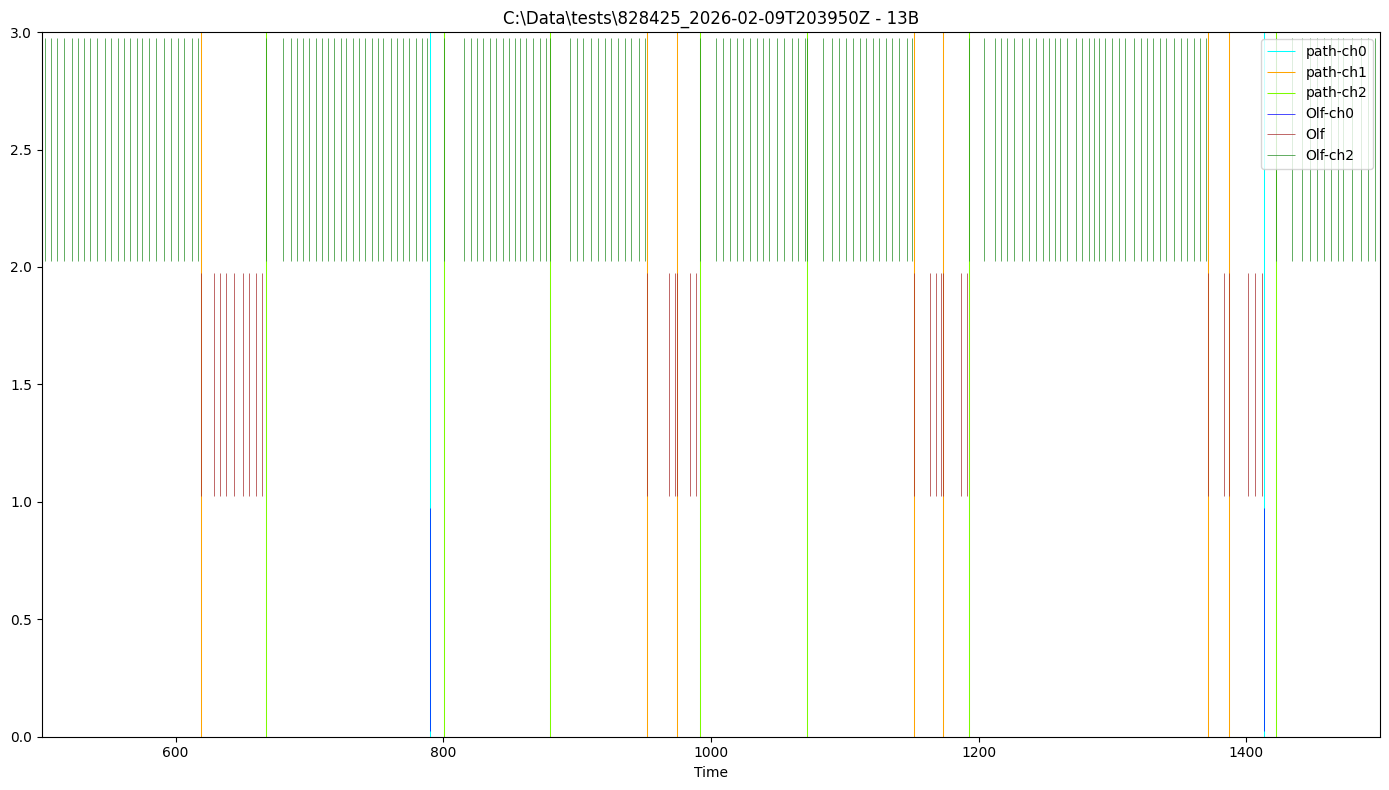

Loaded rig info: Computer - DT300539, Rig - 12C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          31.0      31.0          1.0     0.018191    0.020127      0.00752   
1         143.0     143.0          1.0     4.330902    4.014084      0.00352   
2         175.0     175.0          1.0     3.237928    4.093410      0.00352   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            31.0          1.0     0.032320    0.063557     0.009504  
1           143.0          1.0    11.409808   21.300362     0.009504  
2           175.0          1.0    22.326207   32.383317     0.009536  


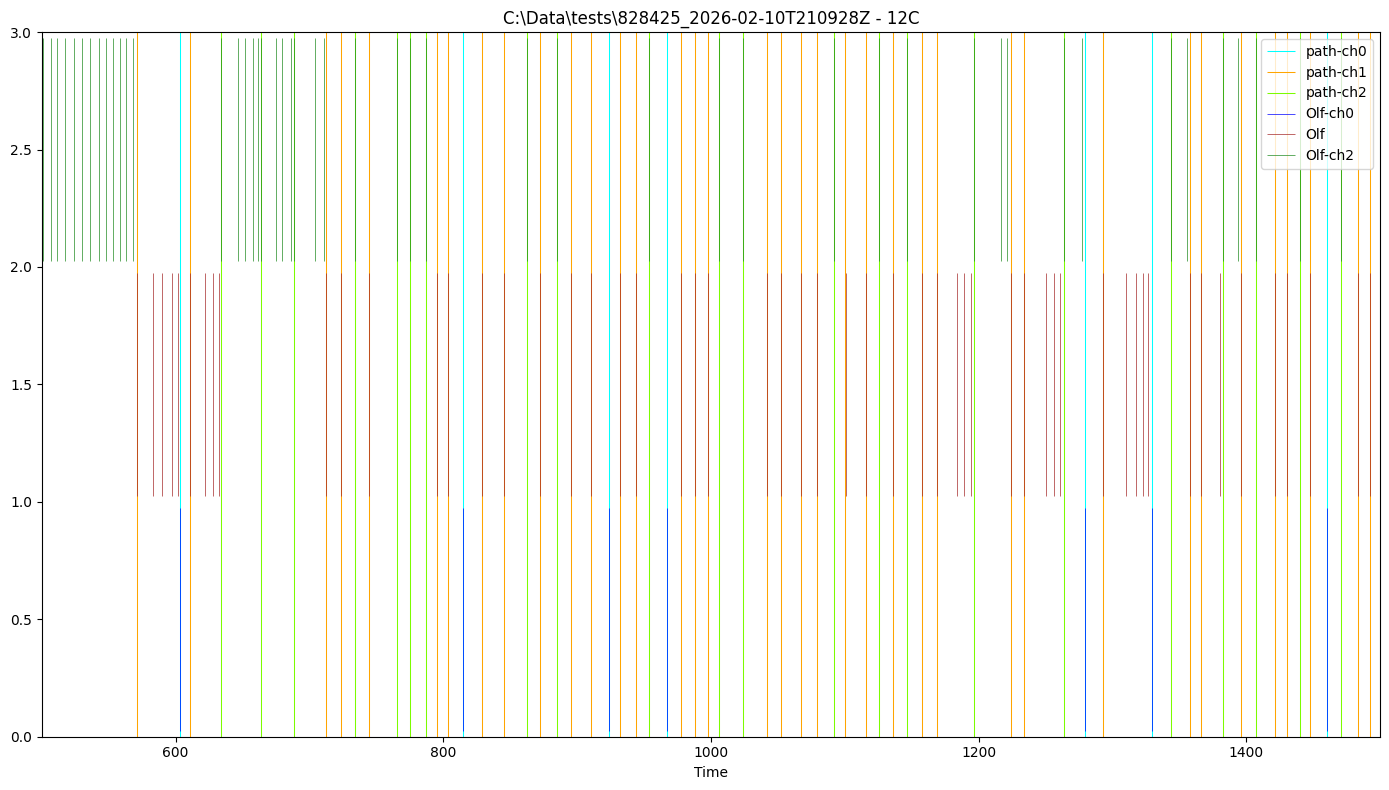

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          13.0      13.0     1.000000     0.014811    0.008685     0.006880   
1         190.0     189.0     0.994737     1.797745    3.191653     0.001888   
2         422.0     422.0     1.000000     0.591767    1.936169     0.001888   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            13.0      1.00000     0.019897    0.011951     0.009888  
1           190.0      1.00000     8.982560   10.435231     0.009888  
2           421.0      0.99763    25.598736   21.390588     0.009888  


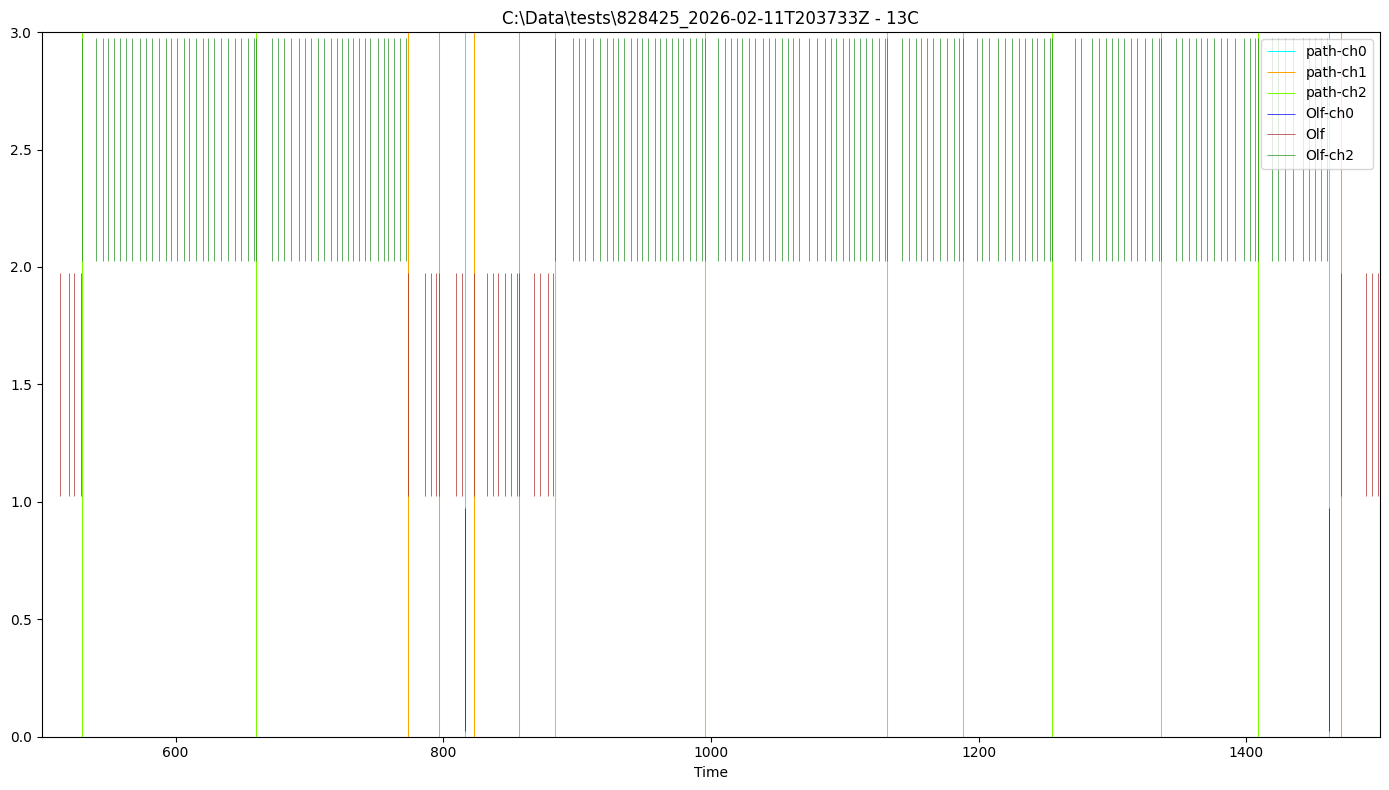

Loaded rig info: Computer - DT300562, Rig - 13B
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          19.0      19.0          1.0     0.015166    0.012812     0.007584   
1         191.0     191.0          1.0     3.047992    7.627177     0.002592   
2         371.0     371.0          1.0     1.200821    2.718193     0.002592   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            19.0     1.000000     0.026745    0.017931     0.011584  
1           191.0     1.000000     7.268884    8.936409     0.010592  
2           370.0     0.997305    21.664686   19.780441     0.010592  


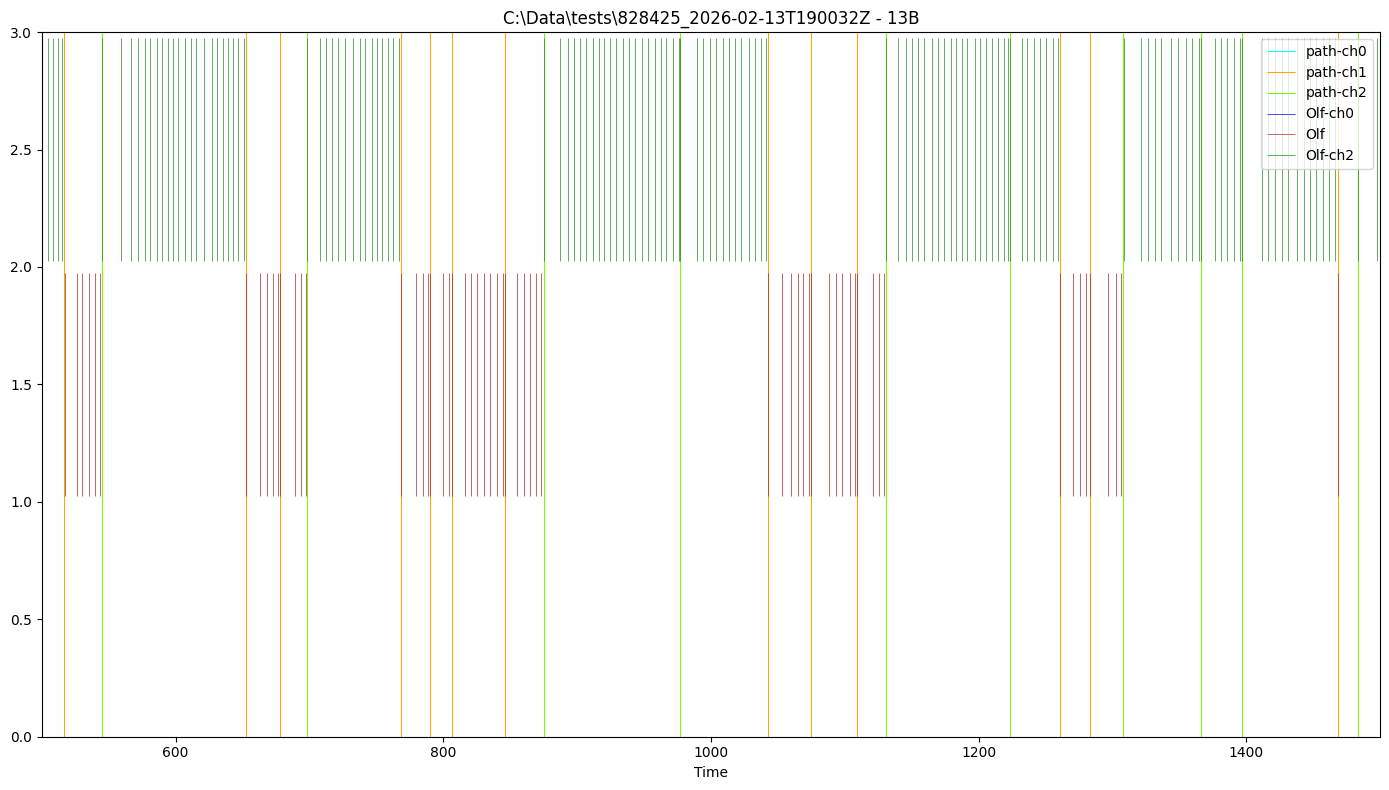

Loaded rig info: Computer - DT300557, Rig - 12D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          32.0      32.0     1.000000     0.014597    0.020565     0.006656   
1         159.0     159.0     1.000000     3.911652    3.031265     0.001664   
2         203.0     202.0     0.995074     2.978566    3.260915     0.002656   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            32.0          1.0     0.663786    2.462659     0.009664  
1           159.0          1.0     0.825889    3.406916     0.010656  
2           203.0          1.0    15.719424   24.750982     0.010656  


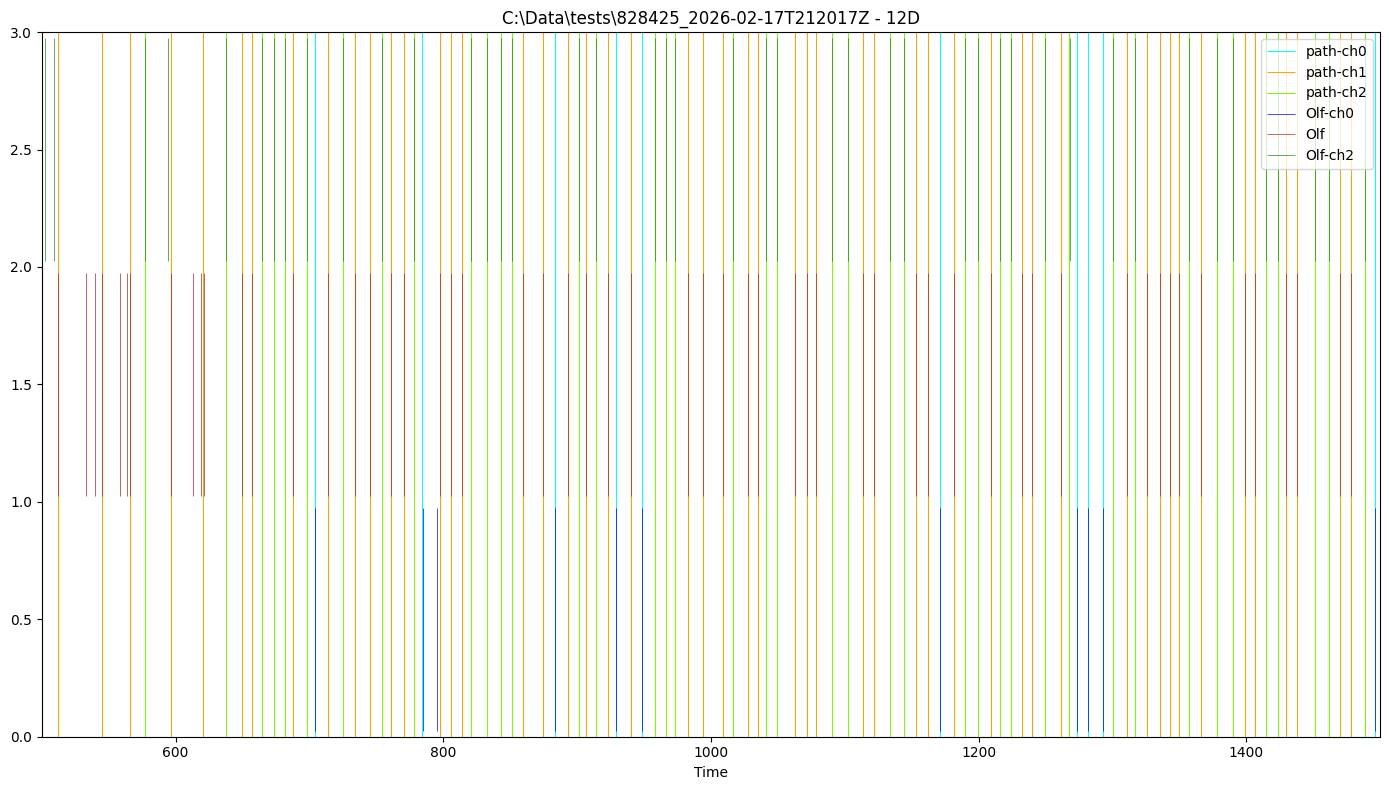

Loaded rig info: Computer - DT300539, Rig - 12C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0          17.0      17.0          1.0     0.012339    0.005284     0.009280   
1         161.0     161.0          1.0     2.957675    4.533631     0.002272   
2         207.0     207.0          1.0     2.131312    4.094273     0.002272   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0            17.0          1.0     0.018456    0.007493      0.01328  
1           161.0          1.0    30.102282   46.163274      0.00928  
2           207.0          1.0    29.091212   29.590402      0.00928  


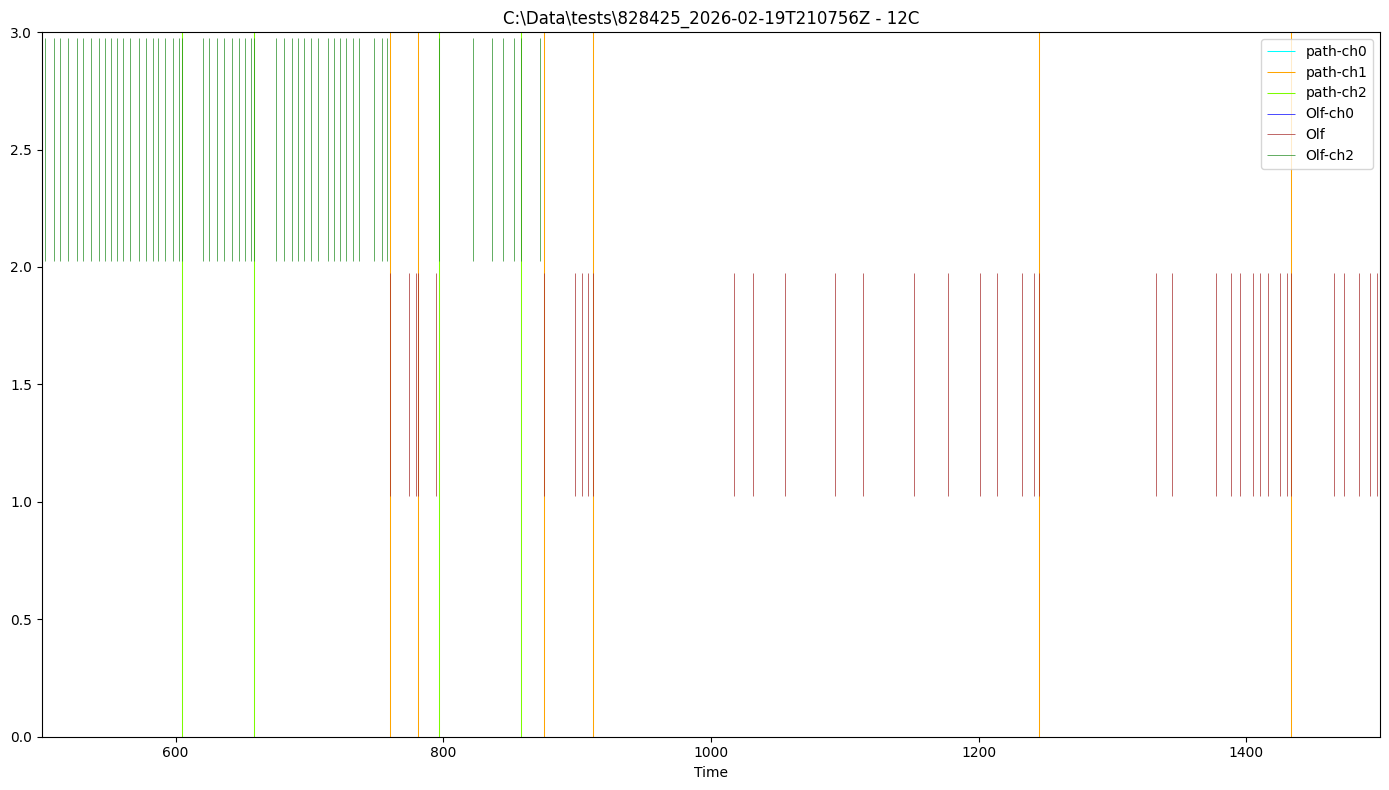

Loaded rig info: Computer - DT300185, Rig - 13D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         279.0     279.0          1.0     0.006426    0.010341      0.00352   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           238.0     0.853047    30.488326   36.879336     0.009536  


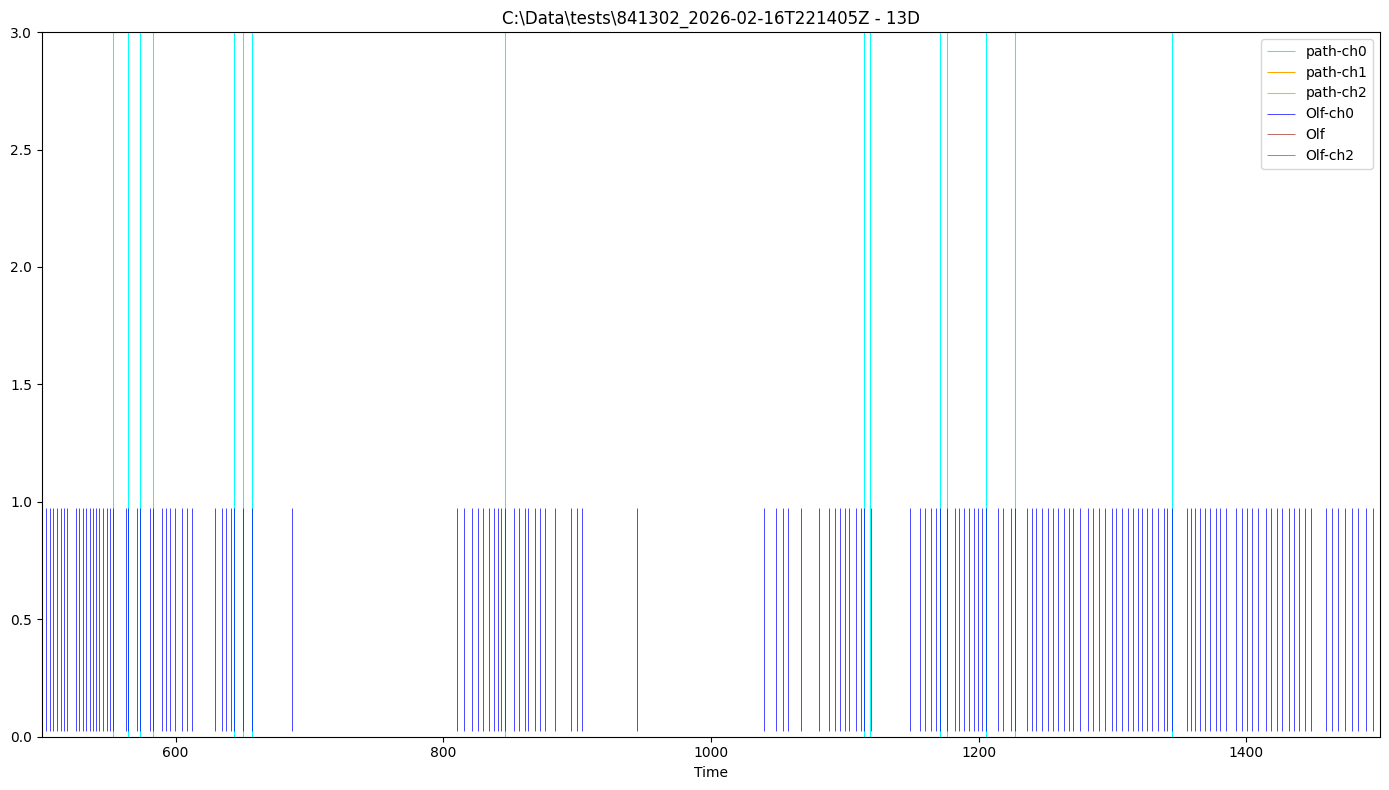

Loaded rig info: Computer - DT300185, Rig - 13D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         599.0     599.0          1.0     0.008398    0.010267     0.002368   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           599.0          1.0    48.458025    71.27345     0.009376  


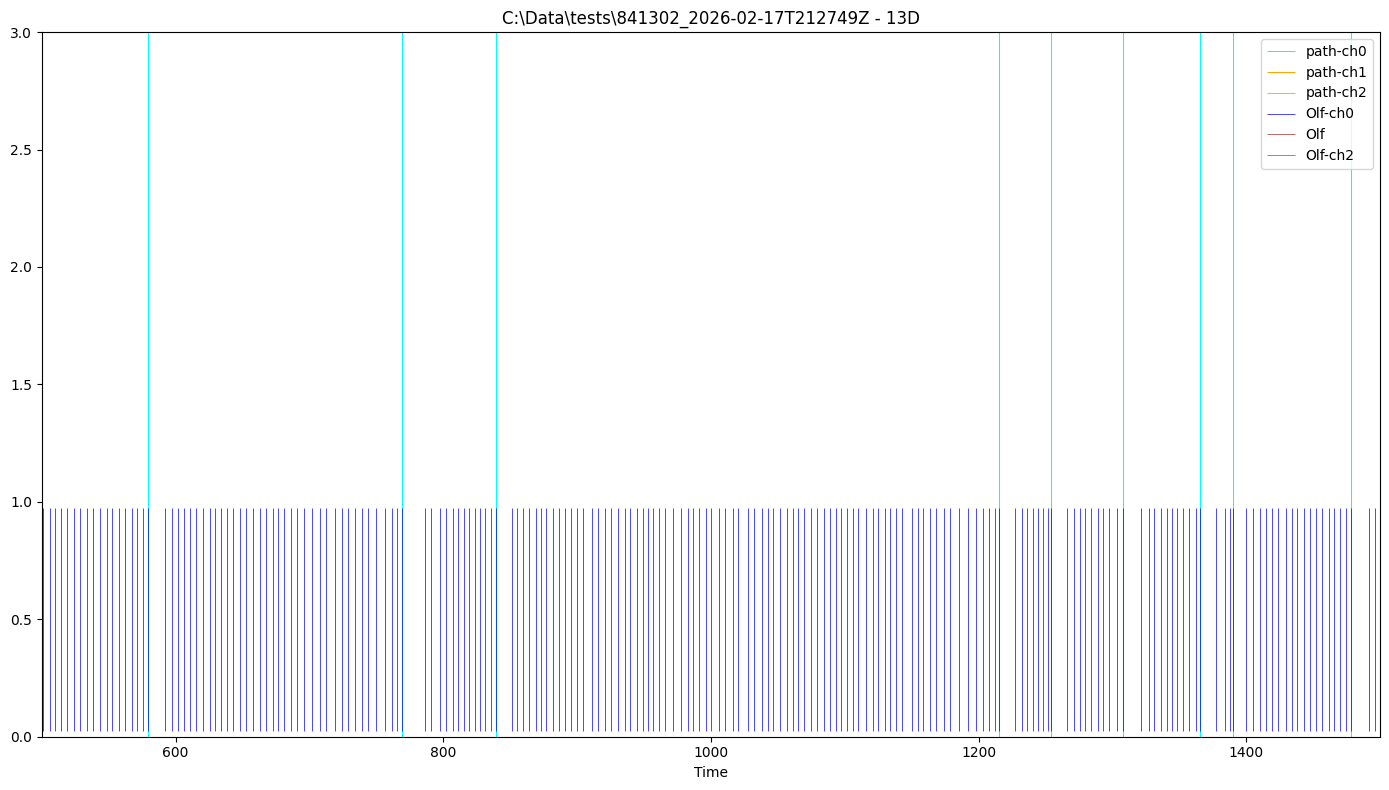

Loaded rig info: Computer - DT300185, Rig - 13D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         450.0     450.0          1.0     0.008096    0.010656     0.003008   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           450.0          1.0    64.561637   79.842153     0.010016  


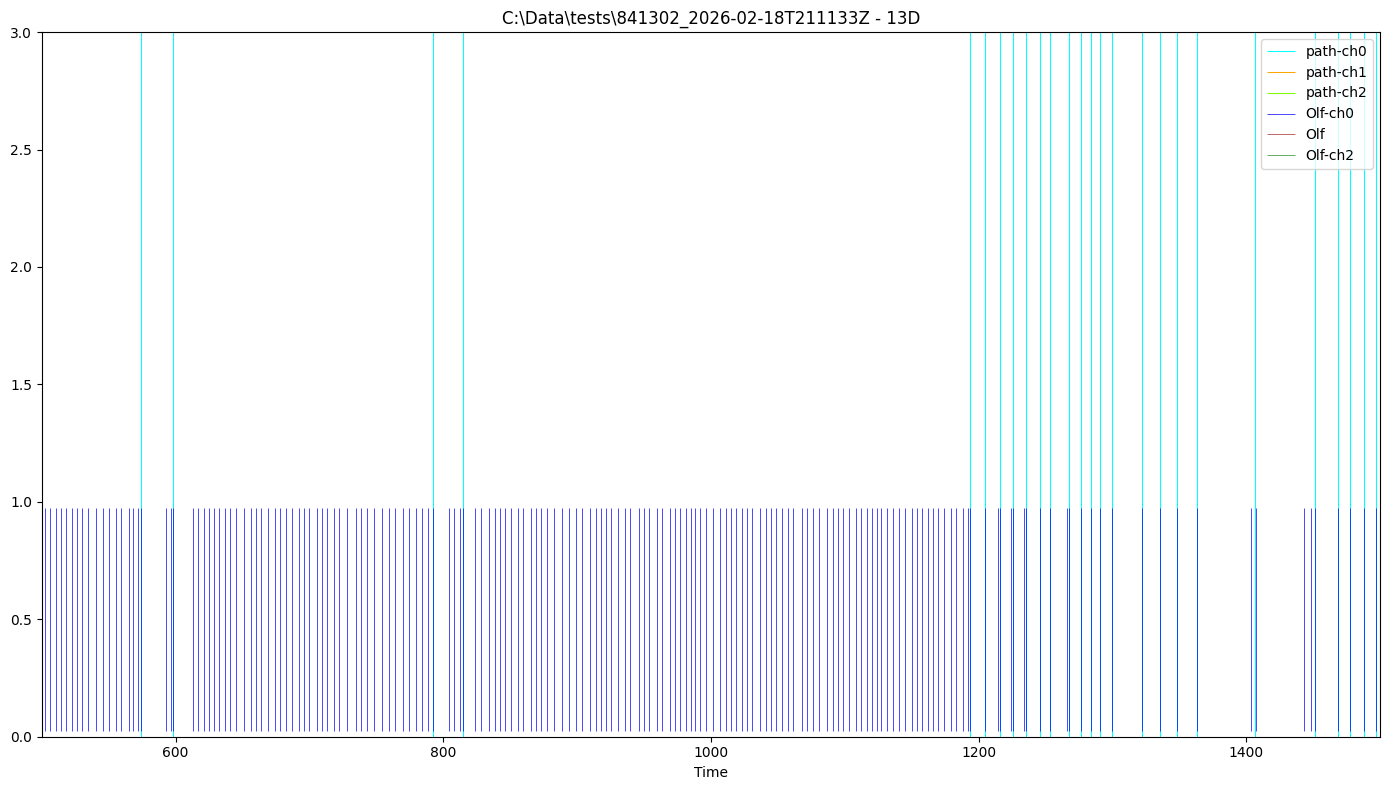

Loaded rig info: Computer - DT300185, Rig - 13D
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         559.0     559.0          1.0     0.007343    0.009397     0.003072   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           559.0          1.0     12.26798   12.350484     0.010048  


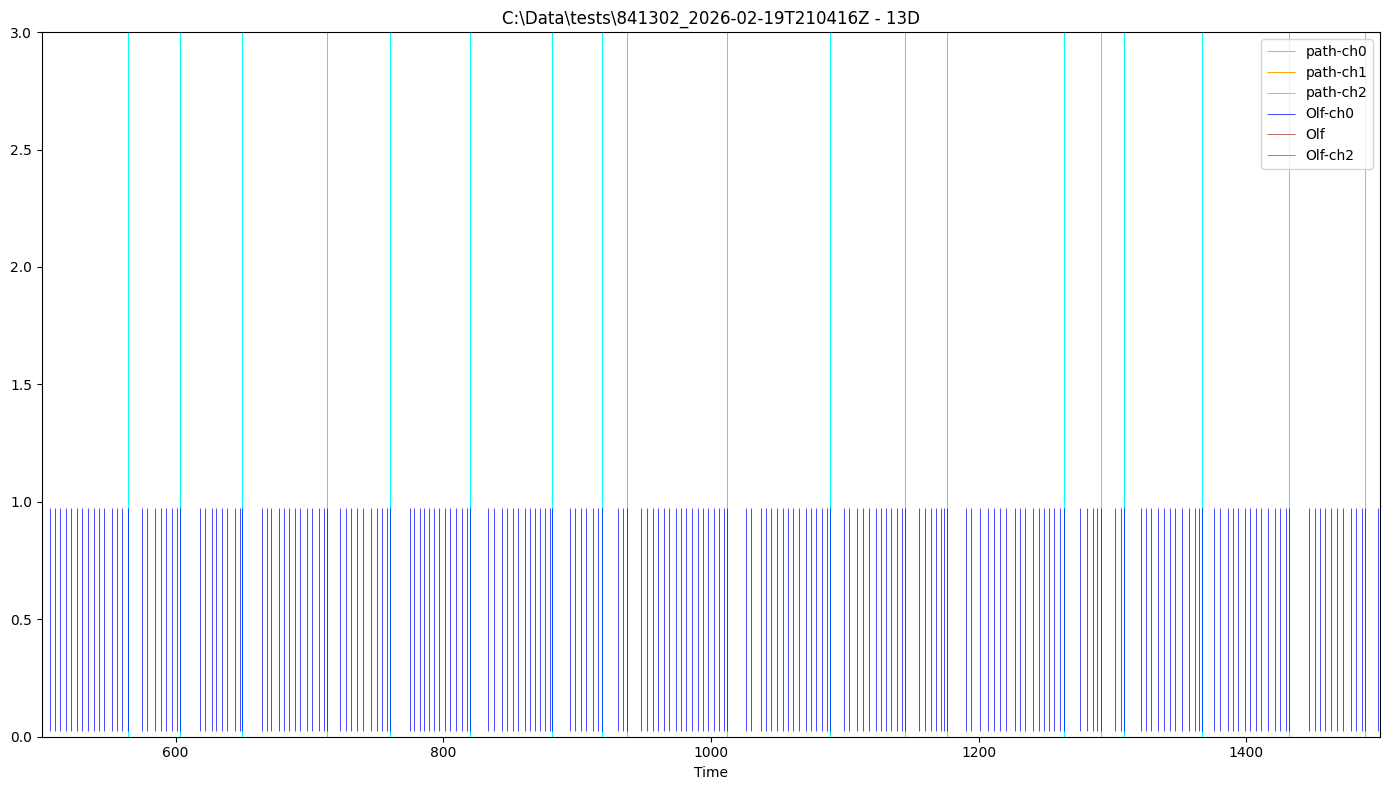

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         387.0     387.0          1.0     0.005404    0.008257     0.003232   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           384.0     0.992248   675.526131   536.83523      0.01024  


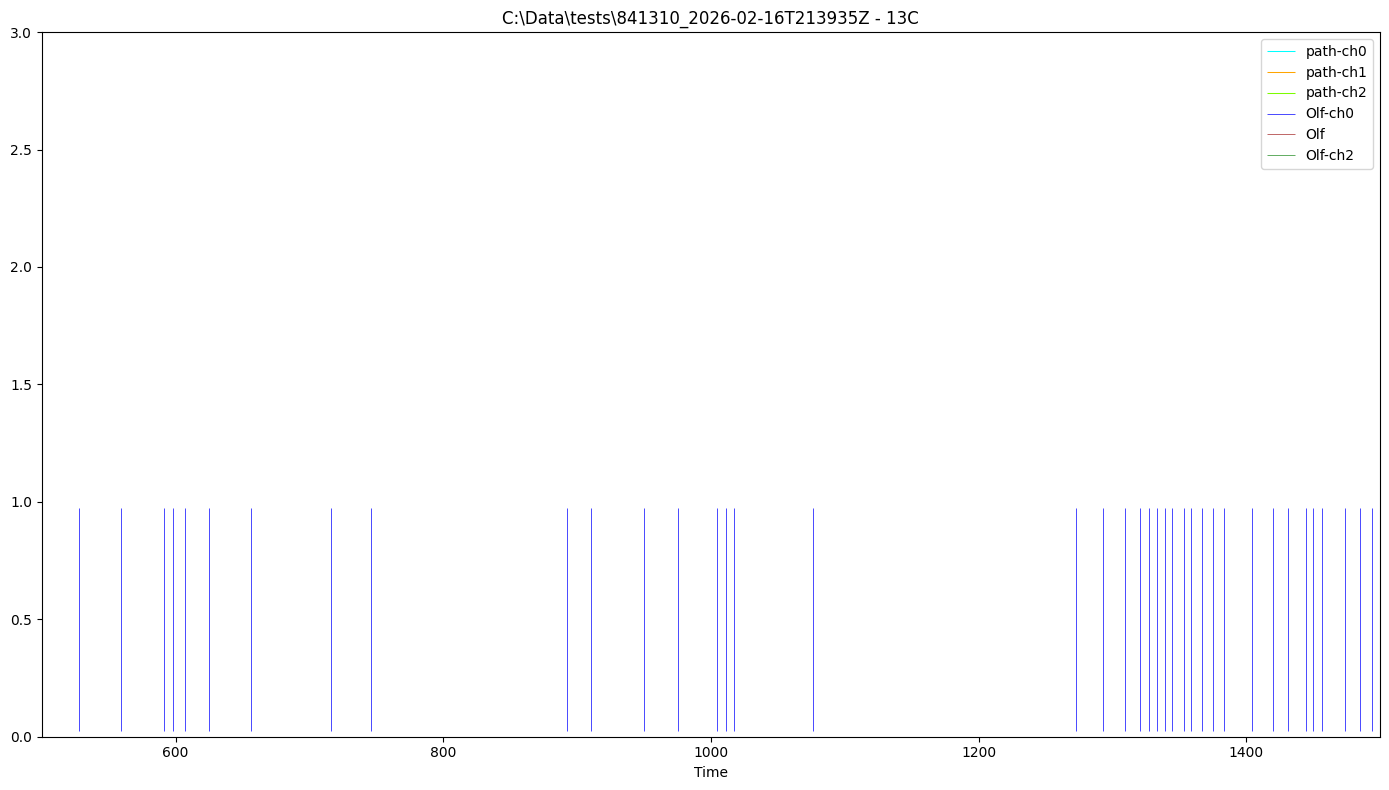

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         559.0     559.0          1.0     0.007616    0.009479     0.003392   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           554.0     0.991055   195.272056  218.557293     0.009376  


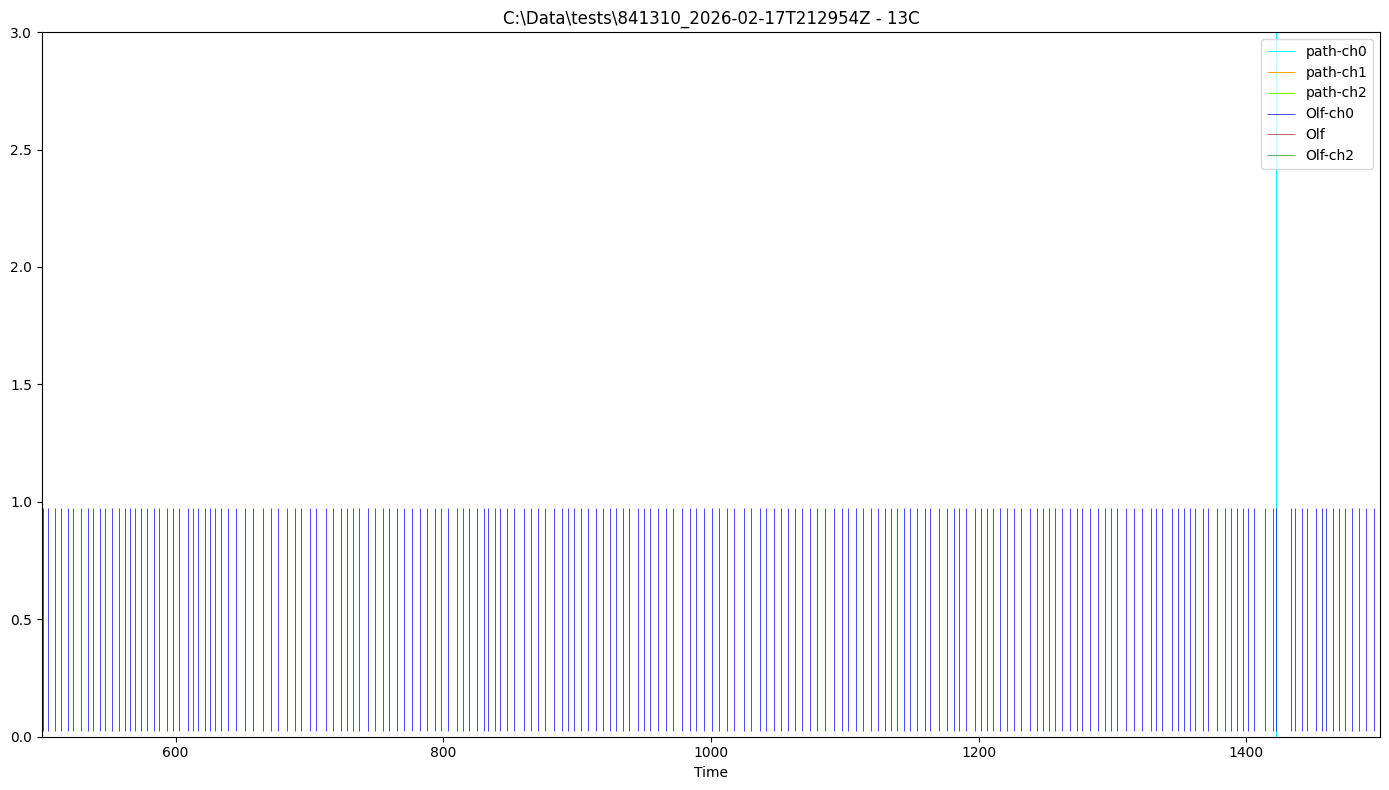

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         615.0     615.0          1.0     0.005544    0.007759      0.00208   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           615.0          1.0   417.986447  380.399351      0.01008  


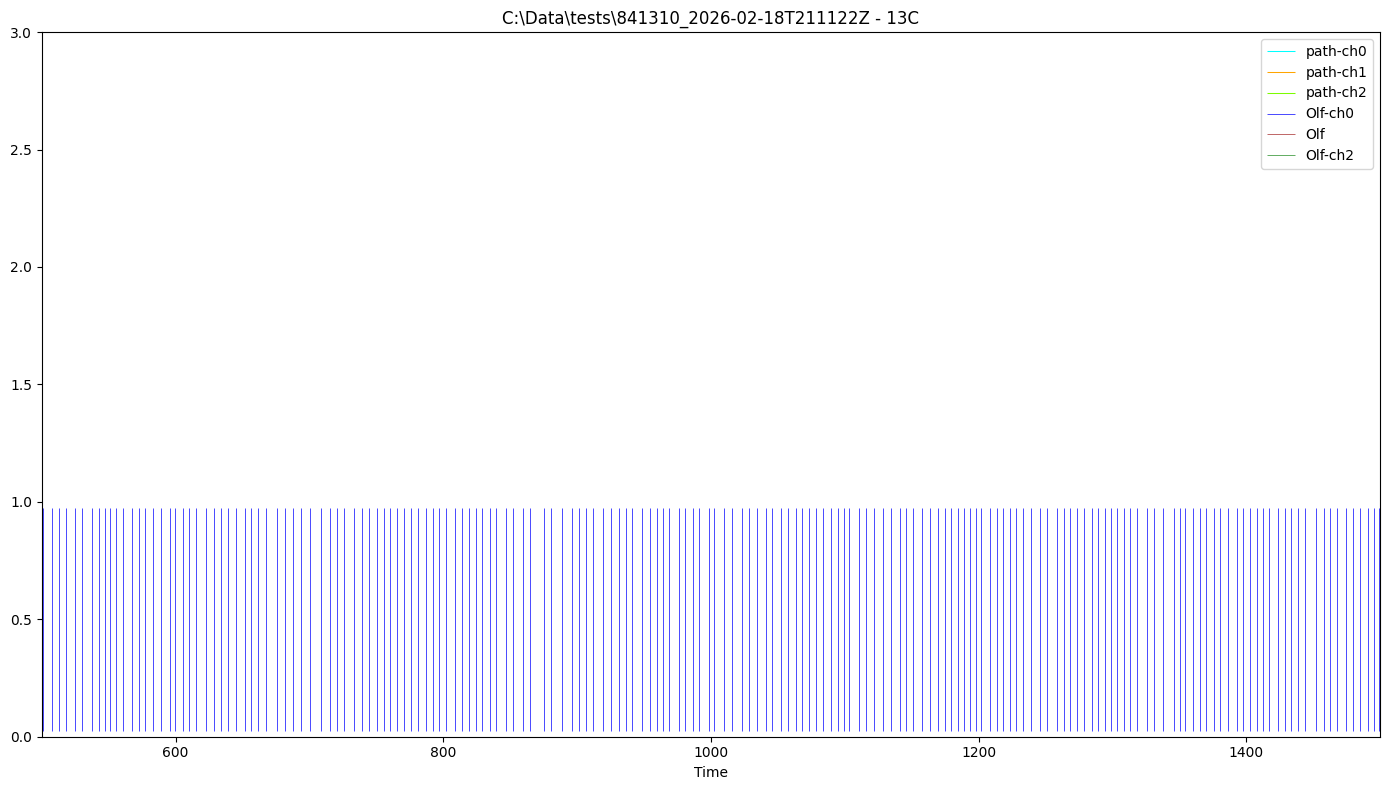

Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  mode_delta1  \
channel                                                                        
0         581.0     581.0          1.0      0.00639    0.010568      0.00304   

         matched2  match_rate2  mean_delta2  std_delta2  mode_delta2  
channel                                                               
0           578.0     0.994836    30.217493   30.967729     0.010048  


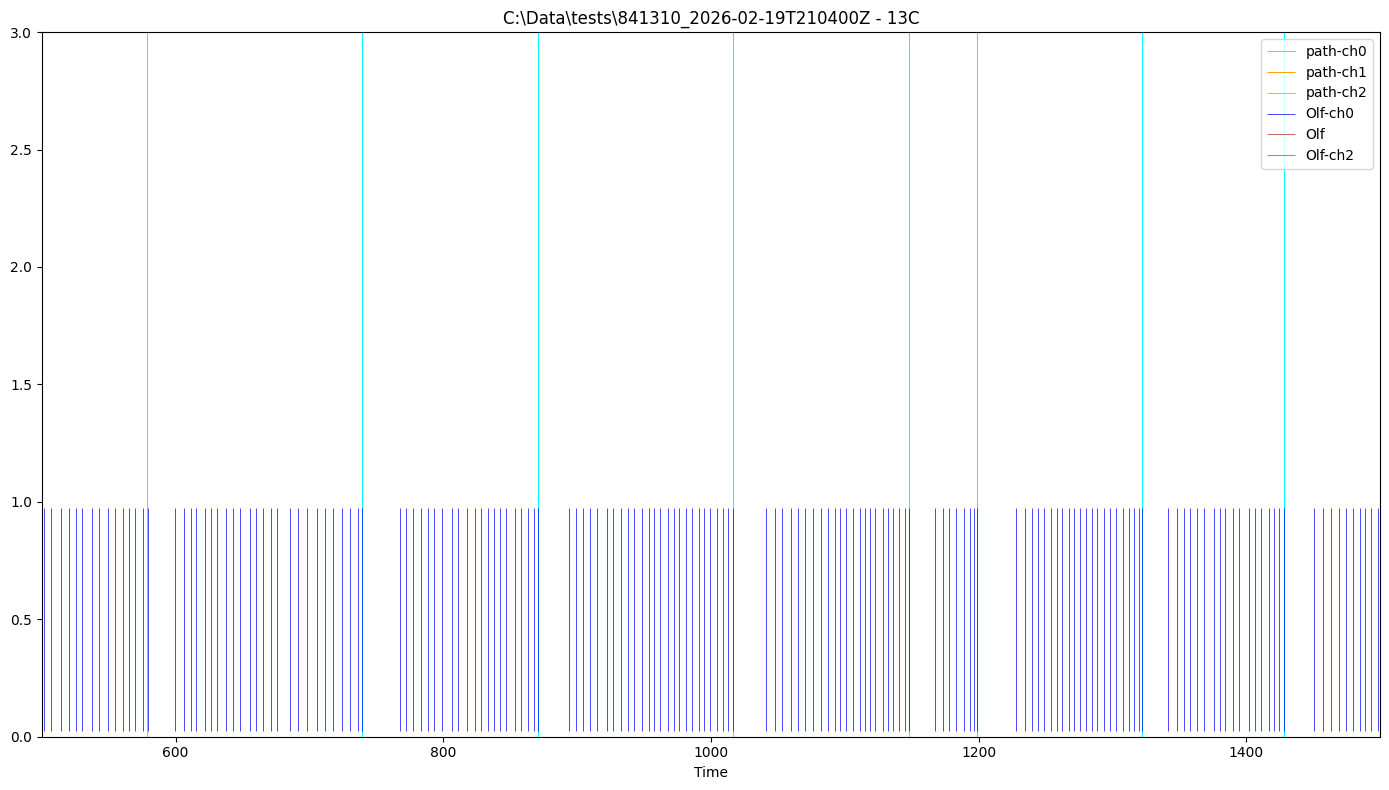

In [27]:
# Analysis of all tests inside a given directory

main_path = Path(r"C:\Data\tests")

for session_dir in main_path.iterdir():
    rig = get_rig_n(str(session_dir))
    run_analysis_in_single_folder(str(session_dir), rig_n=rig, xlim=(500,1500))

  